<a href="https://colab.research.google.com/github/AdnanAnwarR/practice_DS/blob/main/Day_15_Advance_Data_Visualization_Techniques_Hands_on_Adnan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 15 Solution: Advanced Data Visualization Techniques

## 🎯 Learning Objectives
1. Create **Multiclass Visualizations** with multiple encoding channels
2. Apply **Enhanced Matplotlib & Seaborn** techniques (styles, annotations, spines)
3. Master **Discrete and Continuous Color** palettes
4. Build **Faceted Charts** using wraps and grids
5. Export publication-ready figures

## Setup

In [1]:
# Uncomment to install if needed
# !pip install matplotlib seaborn plotly -q

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
import numpy as np

# Load datasets we'll use
titanic = sns.load_dataset('titanic')
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')
penguins = sns.load_dataset('penguins').dropna()

print("✅ All libraries and datasets loaded!")

✅ All libraries and datasets loaded!


In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
pd.set_option('display.max_columns', None)

In [7]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


---

# Part 1: Multiclass Visualization 🎨

**Goal:** Visualize data with 3+ categories using multiple encoding channels (color, shape, size)

## Task 1a: Multiclass Scatter Plot

**Dataset:** `iris` (3 species of flowers)

**Goal:** Create a scatter plot showing sepal length vs sepal width for all 3 species.

**Key techniques:**
- `hue='species'` - Color encoding for categories
- `style='species'` - Different marker shapes per category
- Multiple visual channels help distinguish overlapping categories

In [8]:
iris.head(20)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [9]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [10]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


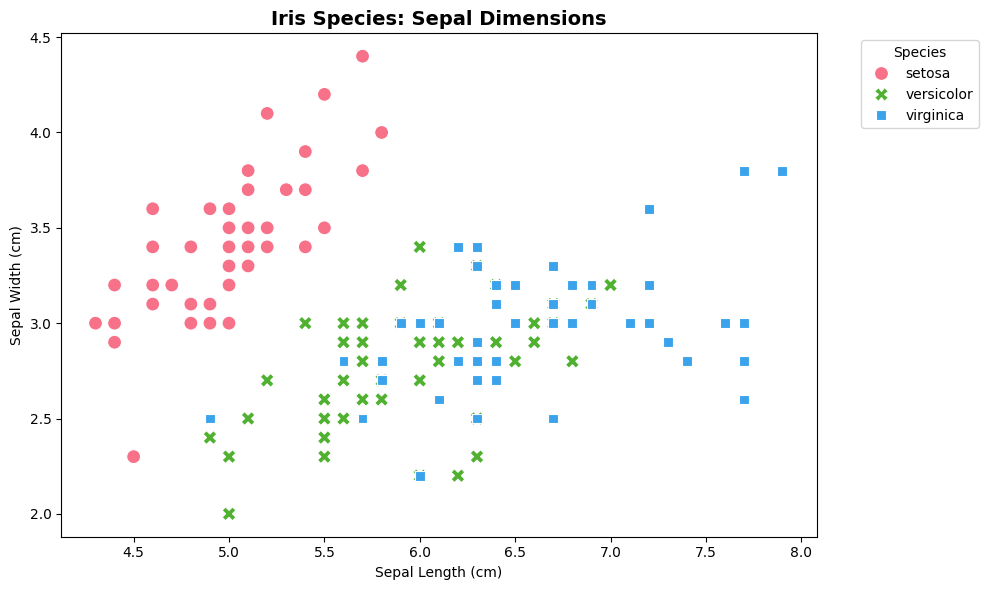

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width',
                hue='species', style='species', s=100, palette='husl')
plt.title('Iris Species: Sepal Dimensions', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [46]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Text(0, 0.5, 'Age')

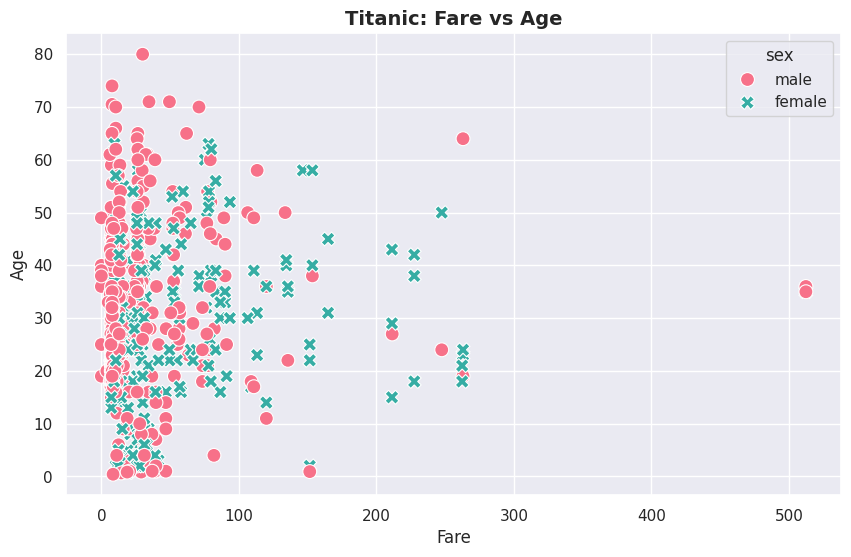

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=titanic, x='fare', y='age',
                hue='sex', style='sex', s=100, palette='husl')
plt.title('Titanic: Fare vs Age', fontsize=14, fontweight='bold')
plt.xlabel('Fare')
plt.ylabel('Age')

In [ ]:
# Membuat figure dengan ukuran 10 inci lebar x 6 inci tinggi
plt.figure(figsize=(10, 6))

# Membuat scatter plot menggunakan seaborn untuk dataset iris
sns.scatterplot(
    data=iris,                    # Dataset iris (bunga iris)
    x='sepal_length',             # Sumbu X: panjang sepal (daun kelopak) dalam cm
    y='sepal_width',              # Sumbu Y: lebar sepal dalam cm
    hue='species',                # Membedakan spesies berdasarkan warna
    style='species',              # Membedakan spesies berdasarkan bentuk marker
    s=100,                        # Ukuran marker = 100 point
    palette='husl'                # Palet warna 'husl' (warna-warna cerah terdistribusi merata)
)

# Memberi judul plot dengan ukuran font 14 dan tebal
plt.title('Iris Species: Sepal Dimensions', fontsize=14, fontweight='bold')

# Memberi label sumbu X (Sepal Length (cm) = Panjang Sepal dalam cm)
plt.xlabel('Sepal Length (cm)')

# Memberi label sumbu Y (Sepal Width (cm) = Lebar Sepal dalam cm)
plt.ylabel('Sepal Width (cm)')

# Menampilkan legend (keterangan) dengan judul 'Species'
# bbox_to_anchor=(1, 1) : memindahkan legend ke koordinat (1,1) yaitu di luar area plot (pojok kanan atas)
# loc='upper left' : menempelkan sudut kiri-atas legend ke koordinat (1,1)
plt.legend(title='Species', bbox_to_anchor=(1, 1), loc='upper left')

# Mengatur layout agar elemen tidak terpotong (termasuk legend di luar)
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

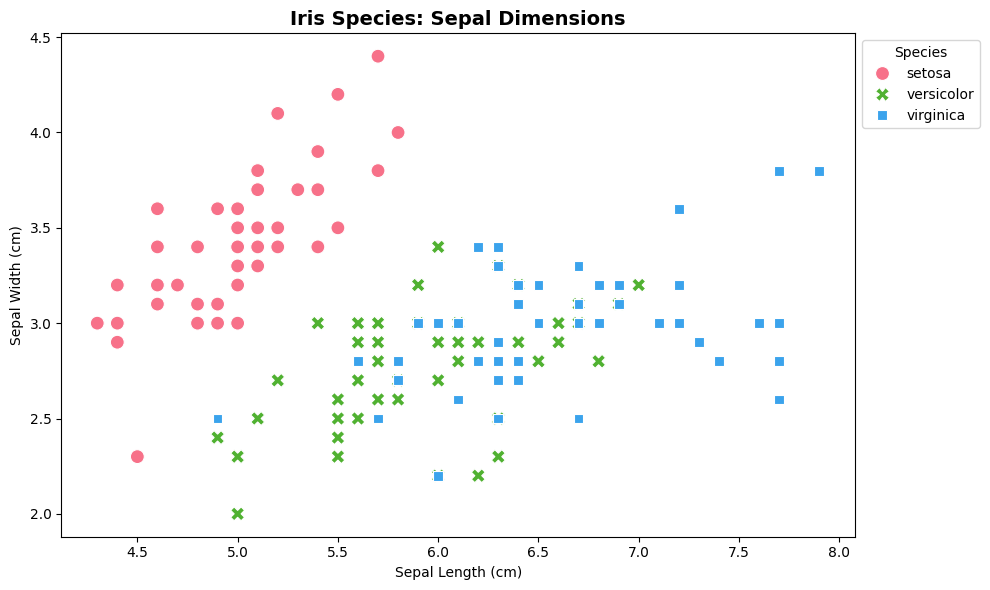

In [12]:
# Membuat figure dengan ukuran 10 inci lebar x 6 inci tinggi
plt.figure(figsize=(10, 6))

# Membuat scatter plot menggunakan seaborn untuk dataset iris
sns.scatterplot(
    data=iris,                    # Dataset iris (bunga iris)
    x='sepal_length',             # Sumbu X: panjang sepal (daun kelopak) dalam cm
    y='sepal_width',              # Sumbu Y: lebar sepal dalam cm
    hue='species',                # Membedakan spesies berdasarkan warna
    style='species',              # Membedakan spesies berdasarkan bentuk marker
    s=100,                        # Ukuran marker = 100 point
    palette='husl'                # Palet warna 'husl' (warna-warna cerah terdistribusi merata)
)

# Memberi judul plot dengan ukuran font 14 dan tebal
plt.title('Iris Species: Sepal Dimensions', fontsize=14, fontweight='bold')

# Memberi label sumbu X (Sepal Length (cm) = Panjang Sepal dalam cm)
plt.xlabel('Sepal Length (cm)')

# Memberi label sumbu Y (Sepal Width (cm) = Lebar Sepal dalam cm)
plt.ylabel('Sepal Width (cm)')

# Menampilkan legend (keterangan) dengan judul 'Species'
# bbox_to_anchor=(1, 1) : memindahkan legend ke koordinat (1,1) yaitu di luar area plot (pojok kanan atas)
# loc='upper left' : menempelkan sudut kiri-atas legend ke koordinat (1,1)
plt.legend(title='Species', bbox_to_anchor=(1, 1), loc='upper left')

# Mengatur layout agar elemen tidak terpotong (termasuk legend di luar)
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

## Task 1b: Multiclass Box Plot vs Violin Plot

**Dataset:** `penguins` (3 species)

**Goal:** Compare body mass distribution across penguin species using both box plot and violin plot side by side.

**Why compare both?**
- **Box plot:** Shows quartiles, median, and outliers clearly
- **Violin plot:** Shows the full distribution shape (bimodal, skewed, etc.)

In [13]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


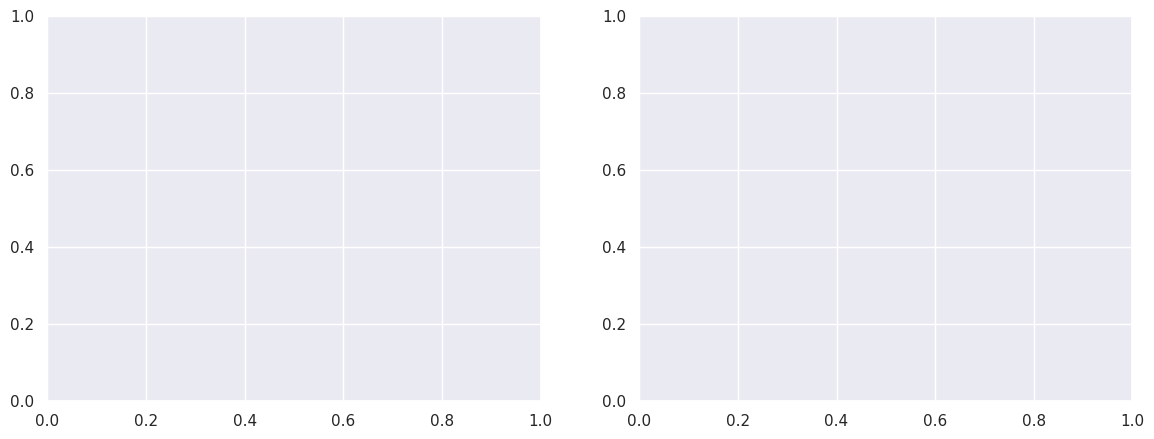

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

/tmp/ipykernel_19322/3357968657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x='species', y='body_mass_g', palette='Set2', ax=axes[0])
/tmp/ipykernel_19322/3357968657.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=penguins, x='species', y='body_mass_g', palette='Set2', inner='box', ax=axes[1])


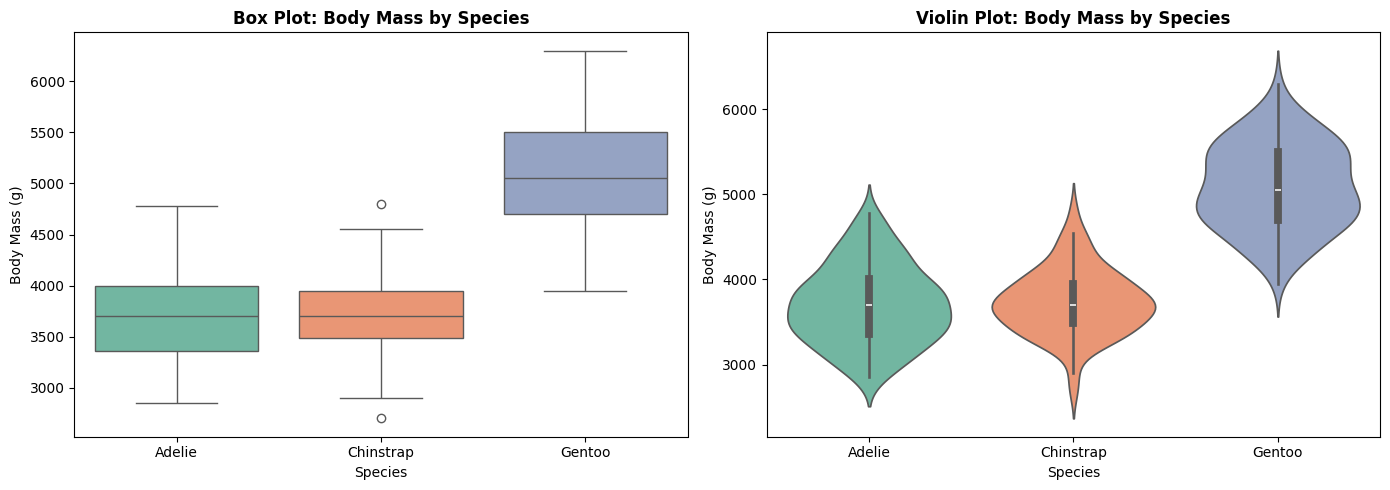

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Box plot
sns.boxplot(data=penguins, x='species', y='body_mass_g', palette='Set2', ax=axes[0])
axes[0].set_title('Box Plot: Body Mass by Species', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Body Mass (g)')

# Right: Violin plot
sns.violinplot(data=penguins, x='species', y='body_mass_g', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot: Body Mass by Species', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Body Mass (g)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_19322/1836583511.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_19322/1836583511.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


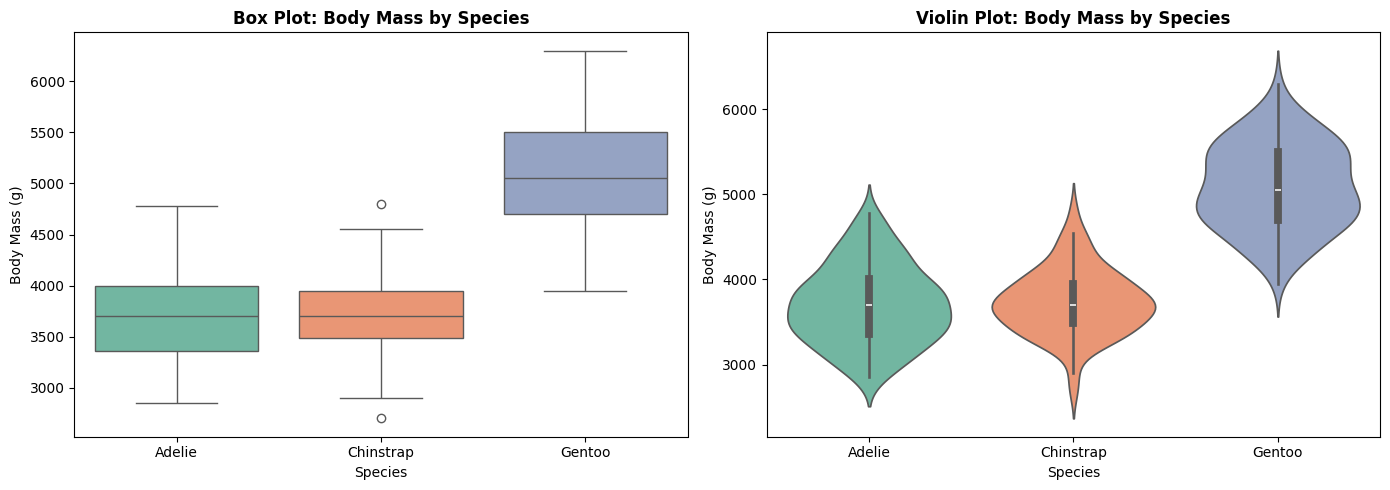

In [15]:
# Membuat figure dengan 1 baris dan 2 kolom subplot
# figsize=(14, 5) : lebar 14 inci x tinggi 5 inci
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ========== SUBPLOT KIRI (INDEX 0) ==========
# Membuat box plot menggunakan seaborn
sns.boxplot(
    data=penguins,                # Dataset penguins
    x='species',                  # Sumbu X: spesies penguin (Adelie, Chinstrap, Gentoo)
    y='body_mass_g',              # Sumbu Y: massa tubuh (gram)
    palette='Set2',               # Palet warna soft dan colorblind-friendly
    ax=axes[0]                    # Menggambar pada subplot kiri (index 0)
)

# Memberi judul untuk subplot kiri
axes[0].set_title('Box Plot: Body Mass by Species', fontsize=12, fontweight='bold')

# Memberi label sumbu X (Species = Spesies)
axes[0].set_xlabel('Species')

# Memberi label sumbu Y (Body Mass (g) = Massa Tubuh dalam gram)
axes[0].set_ylabel('Body Mass (g)')

# ========== SUBPLOT KANAN (INDEX 1) ==========
# Membuat violin plot (kombinasi box plot + distribusi kepadatan) menggunakan seaborn
sns.violinplot(
    data=penguins,                # Dataset penguins
    x='species',                  # Sumbu X: spesies penguin
    y='body_mass_g',              # Sumbu Y: massa tubuh (gram)
    palette='Set2',               # Palet warna soft dan colorblind-friendly
    inner='box',                  # Menampilkan box plot mini di dalam violin plot
                                 # 'box' = menampilkan median, Q1, Q3, whisker
    ax=axes[1]                    # Menggambar pada subplot kanan (index 1)
)

# Memberi judul untuk subplot kanan
axes[1].set_title('Violin Plot: Body Mass by Species', fontsize=12, fontweight='bold')

# Memberi label sumbu X (Species = Spesies)
axes[1].set_xlabel('Species')

# Memberi label sumbu Y (Body Mass (g) = Massa Tubuh dalam gram)
axes[1].set_ylabel('Body Mass (g)')

# Mengatur layout agar subplot tidak terpotong atau tumpang tindih
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

## Task 1c: Grouped Bar Chart

**Dataset:** `tips`

**Goal:** Show count of customers by day, grouped by smoker status.

**Best practices:**
- Order days logically (not alphabetically)
- Use colorblind-friendly palettes
- Add clear labels

In [16]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='day', ylabel='count'>

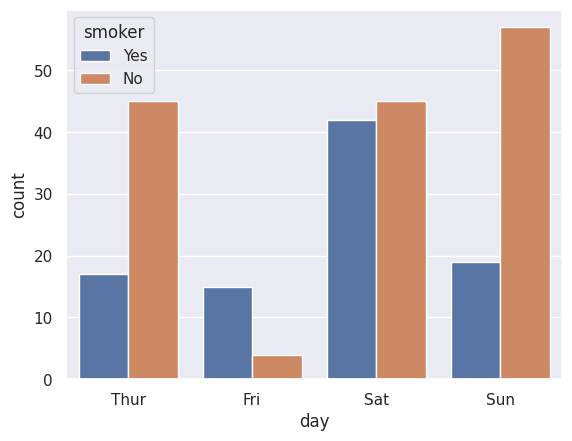

In [50]:
sns.countplot(data=tips, x='day', hue='smoker')


In [53]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='alive', ylabel='count'>

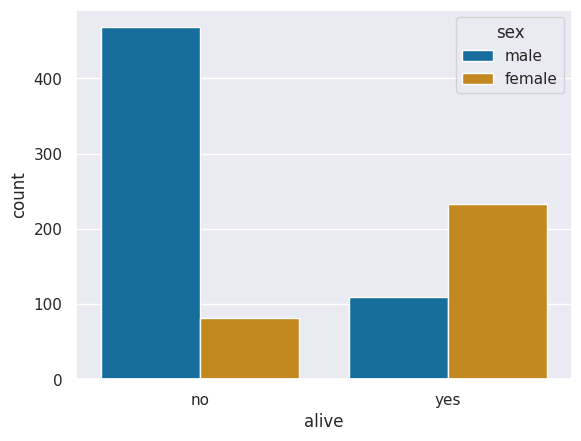

In [55]:
sns.countplot(data=titanic, x='alive', hue='sex', palette='colorblind')

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

57.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

79.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning:

64.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/usr/local/lib/python3.12/dist-packages/seaborn/categor

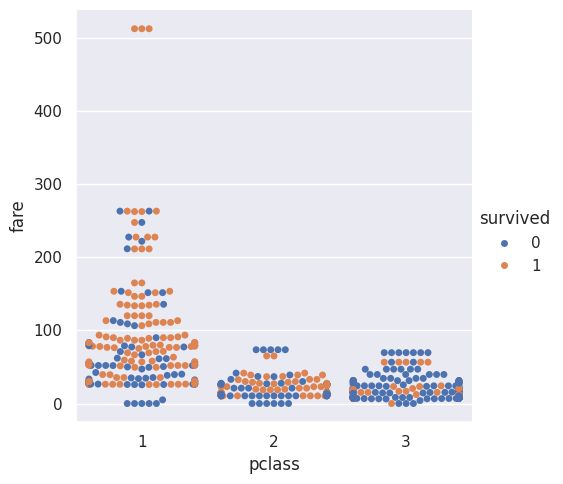

In [56]:
sns.catplot(x="pclass", y="fare",hue= 'survived',kind="swarm",data=titanic)

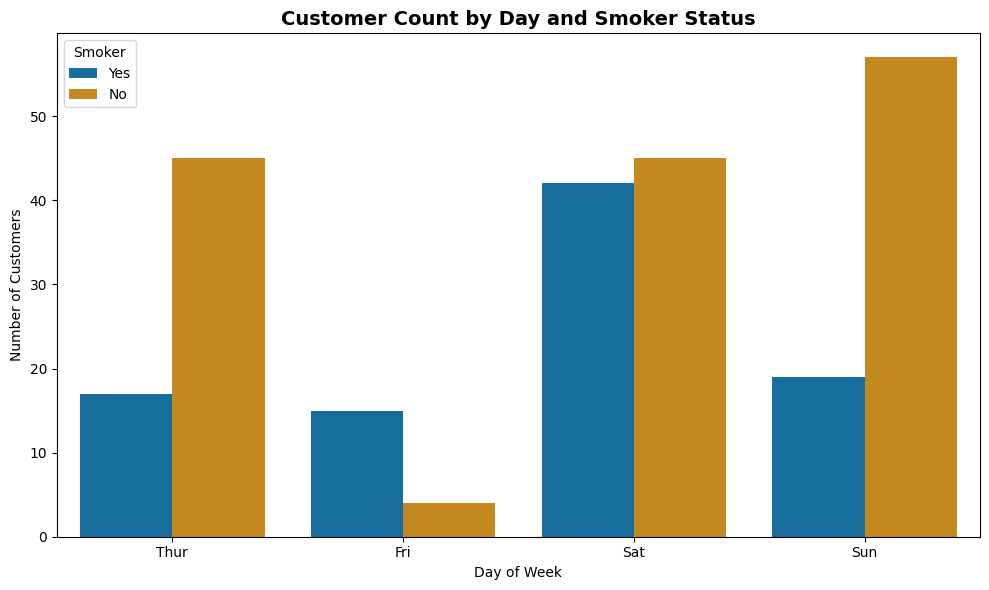

In [17]:
plt.figure(figsize=(10, 6))
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
sns.countplot(data=tips, x='day', hue='smoker', order=day_order, palette='colorblind')
plt.title('Customer Count by Day and Smoker Status', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Customers')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

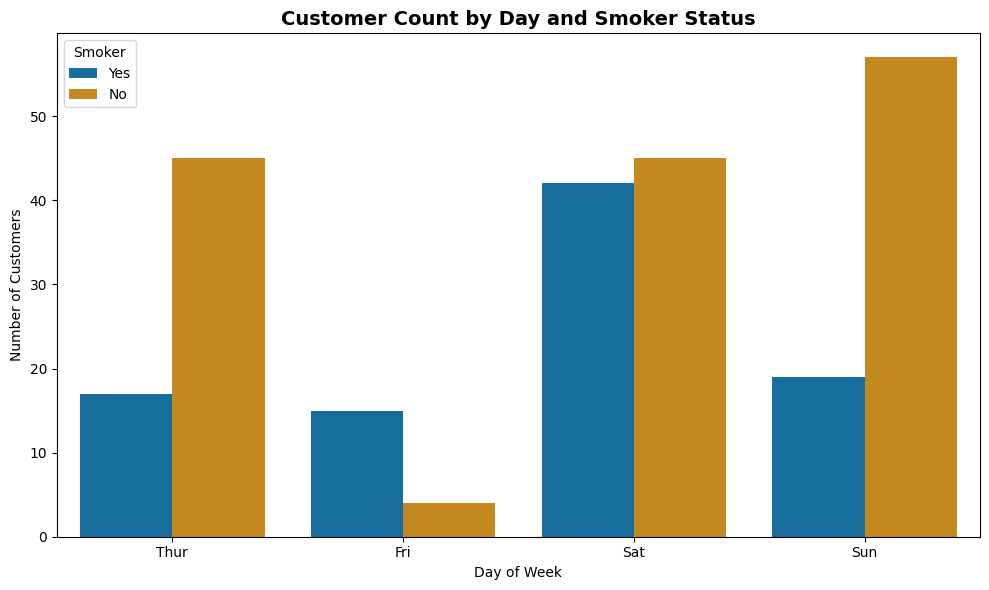

In [18]:
# Membuat figure dengan ukuran 10 inci lebar x 6 inci tinggi
plt.figure(figsize=(10, 6))

# Menentukan urutan hari yang akan ditampilkan pada sumbu X
# (bukan urutan alfabetis, tapi urutan logis dari Kamis hingga Minggu)
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

# Membuat count plot (bar plot yang menunjukkan jumlah/frekuensi) menggunakan seaborn
# countplot = menghitung jumlah kemunculan setiap kategori
sns.countplot(
    data=tips,                    # Dataset tips
    x='day',                      # Sumbu X: hari (Thur, Fri, Sat, Sun)
    hue='smoker',                 # Membedakan warna berdasarkan status perokok (Yes/No)
    order=day_order,              # Urutan kategori pada sumbu X (Thur → Fri → Sat → Sun)
    palette='colorblind'          # Palet warna yang ramah untuk pengguna buta warna
)

# Memberi judul plot dengan ukuran font 14 dan tebal
plt.title('Customer Count by Day and Smoker Status', fontsize=14, fontweight='bold')

# Memberi label sumbu X (Day of Week = Hari dalam seminggu)
plt.xlabel('Day of Week')

# Memberi label sumbu Y (Number of Customers = Jumlah Pelanggan)
plt.ylabel('Number of Customers')

# Menampilkan legend (keterangan) dengan judul 'Smoker'
plt.legend(title='Smoker')

# Mengatur layout agar elemen tidak terpotong
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

---

# Part 2: Enhanced Matplotlib & Seaborn ✨

**Goal:** Apply professional styling, custom annotations, and clean aesthetics

## Task 2a: Apply Different Styles

**Goal:** Create the same line plot with 3 different matplotlib styles.

**Available styles:** 'ggplot', 'seaborn-v0_8-whitegrid', 'fivethirtyeight', 'bmh', 'dark_background', etc.

**Use `plt.style.context()`** to temporarily apply a style without affecting other plots

In [19]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


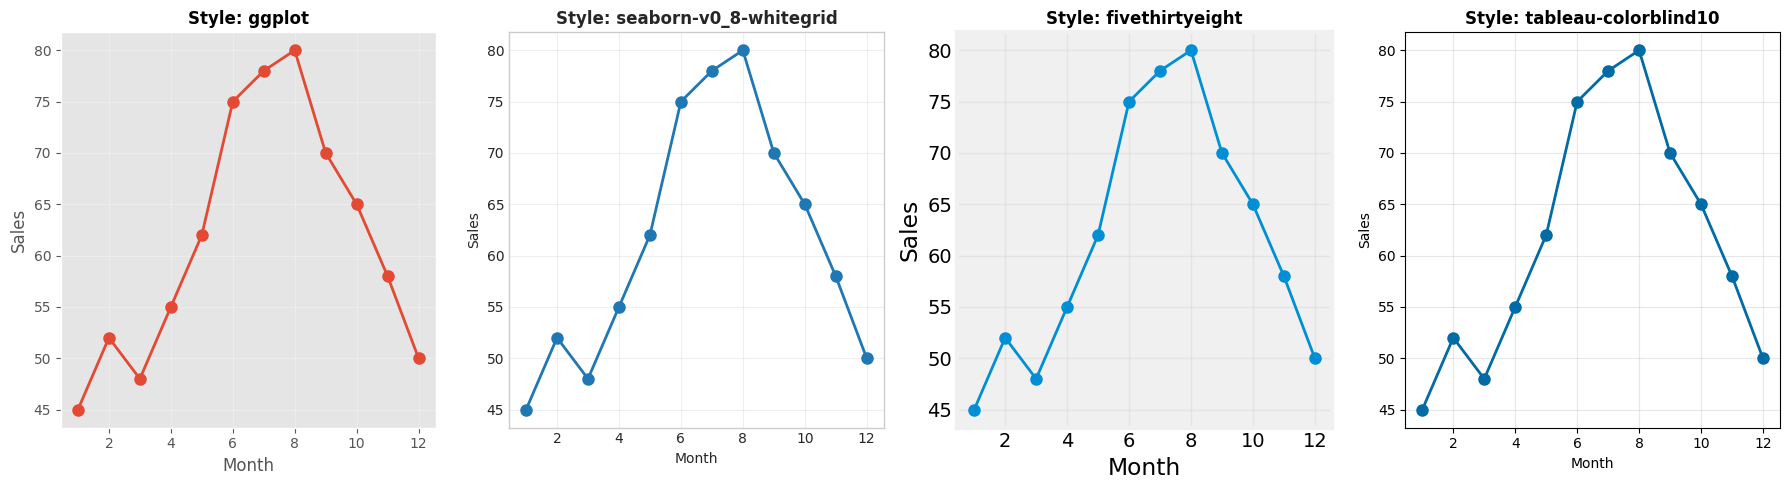

In [20]:
import matplotlib.pyplot as plt

# Sample data
x = range(1, 13)
y = [45, 52, 48, 55, 62, 75, 78, 80, 70, 65, 58, 50]

styles = ['ggplot', 'seaborn-v0_8-whitegrid', 'fivethirtyeight', 'tableau-colorblind10'] # bmh lebih terlihat bedanya

# Kita buat figure-nya dulu tanpa axes
fig = plt.figure(figsize=(18, 5))

for i, style in enumerate(styles):
    with plt.style.context(style):
        # Buat subplot di DALAM context manager
        ax = fig.add_subplot(1, 4, i+1)

        ax.plot(x, y, marker='o', linewidth=2, markersize=8)
        ax.set_title(f'Style: {style}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Month')
        ax.set_ylabel('Sales')
        # Grid biasanya otomatis ikut style, tapi bisa di-force
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

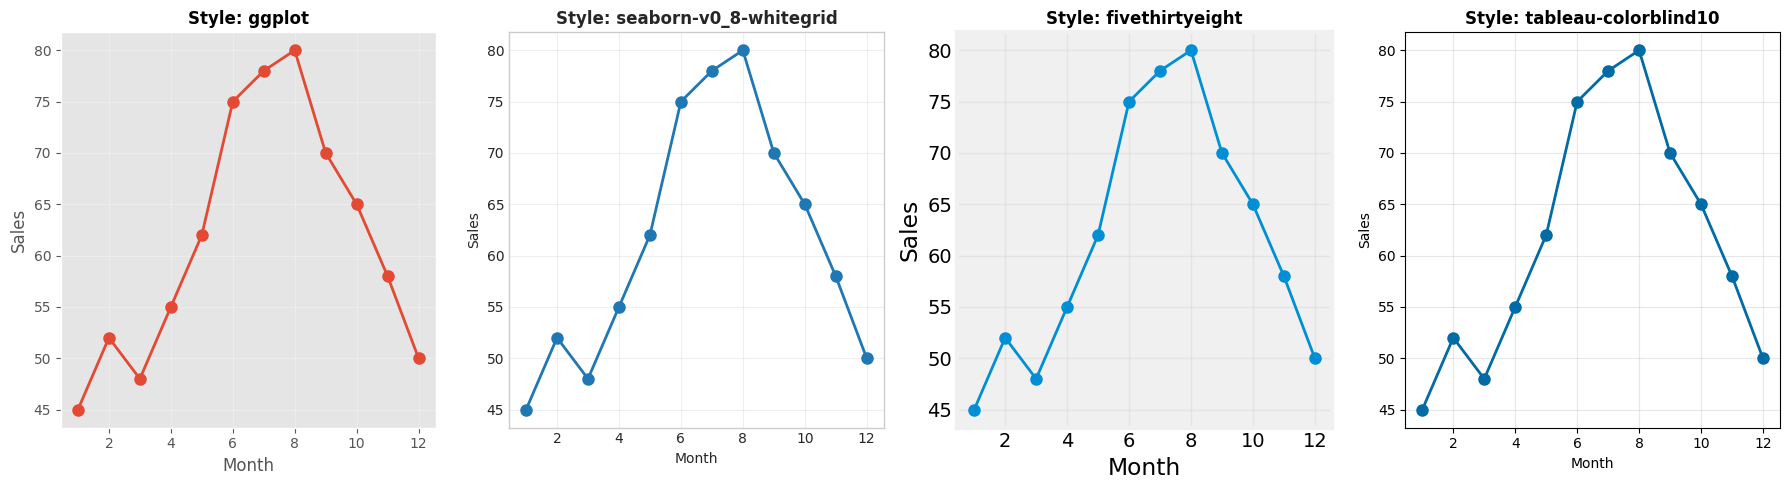

In [21]:
import matplotlib.pyplot as plt

# Sample data - data penjualan bulanan (Januari = bulan 1, Desember = bulan 12)
x = range(1, 13)                   # Bulan 1 sampai 12
y = [45, 52, 48, 55, 62, 75, 78, 80, 70, 65, 58, 50]  # Nilai penjualan per bulan

# Daftar style (tema) yang akan dibandingkan
# 'ggplot'            : gaya dari library R ggplot2 (background abu-abu dgn garis putih)
# 'seaborn-v0_8-whitegrid' : gaya seaborn klasik dengan grid putih di atas background terang
# 'fivethirtyeight'   : gaya dari situs FiveThirtyEight (news site, background gelap)
# 'tableau-colorblind10' : palet warna colorblind-friendly dari Tableau
styles = ['ggplot', 'seaborn-v0_8-whitegrid', 'fivethirtyeight', 'tableau-colorblind10']

# Membuat figure (kanvas) terlebih dahulu tanpa axes (subplot)
# figsize=(18, 5) : lebar 18 inci x tinggi 5 inci untuk menampung 4 plot horizontal
fig = plt.figure(figsize=(18, 5))

# Loop untuk membuat subplot dengan setiap style
for i, style in enumerate(styles):
    # Menggunakan context manager (with) untuk menerapkan style hanya di dalam blok ini
    # Dengan plt.style.context(), style hanya berlaku untuk kode di dalam blok ini
    # Tidak mempengaruhi plot lain di luar loop
    with plt.style.context(style):
        # Membuat subplot pada posisi ke-(i+1) dalam grid 1 baris x 4 kolom
        # i dimulai dari 0, maka i+1 = 1,2,3,4
        ax = fig.add_subplot(1, 4, i+1)

        # Membuat line plot dengan marker lingkaran
        # x = bulan (1-12), y = nilai penjualan
        # linewidth = ketebalan garis = 2 point
        # markersize = ukuran marker = 8 point
        ax.plot(x, y, marker='o', linewidth=2, markersize=8)

        # Memberi judul subplot sesuai nama style (font 12, tebal)
        ax.set_title(f'Style: {style}', fontsize=12, fontweight='bold')

        # Memberi label sumbu X (Month = Bulan)
        ax.set_xlabel('Month')

        # Memberi label sumbu Y (Sales = Penjualan)
        ax.set_ylabel('Sales')

        # Mengaktifkan grid dengan transparansi 30%
        # Grid biasanya otomatis mengikuti style, tapi bisa di-force manual seperti ini
        ax.grid(True, alpha=0.3)

# Mengatur layout agar subplot tidak terpotong atau tumpang tindih
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

## Task 2b: Professional Annotations

**Goal:** Create a line chart with professional annotations highlighting key insights.

**Annotation techniques:**
1. **Arrow annotation** - Point to specific data points
2. **Reference lines** - Mark targets or thresholds
3. **Shaded regions** - Highlight time periods or ranges

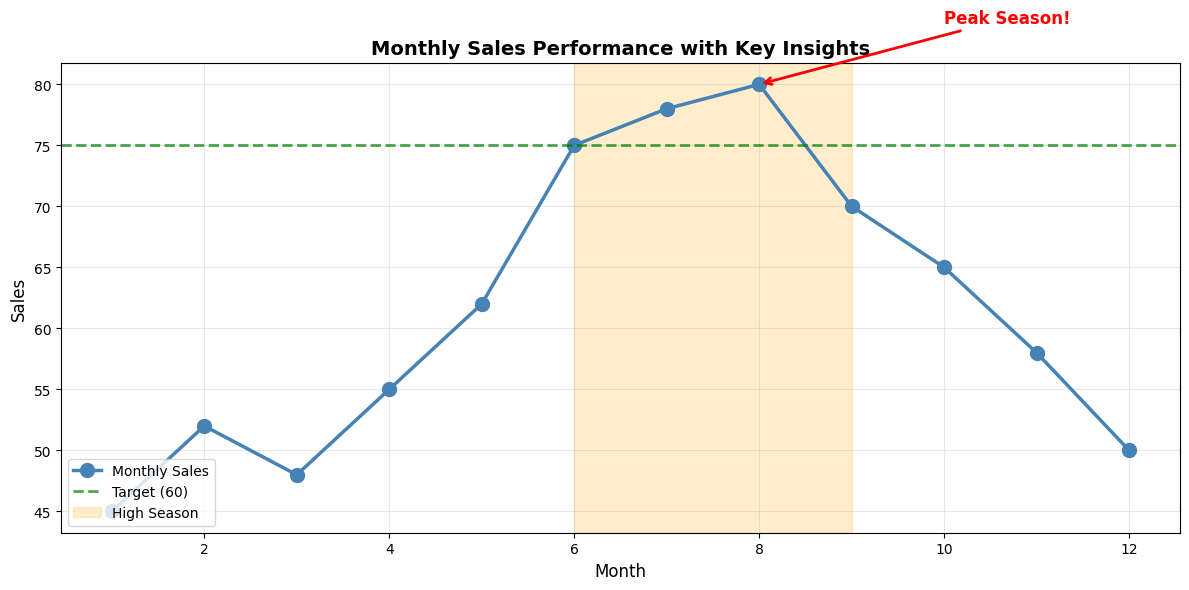

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(x, y, marker='o', linewidth=2.5, markersize=10, color='steelblue', label='Monthly Sales')

# 1. Arrow annotation for peak
plt.annotate('Peak Season!',
             xy=(8, 80), xytext=(10, 85),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12, fontweight='bold', color='red')

# 2. Horizontal target line
plt.axhline(y=75, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Target (60)')

# 3. Shaded region for high season (months 6-9)
plt.axvspan(6, 9, alpha=0.2, color='orange', label='High Season')

plt.title('Monthly Sales Performance with Key Insights', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

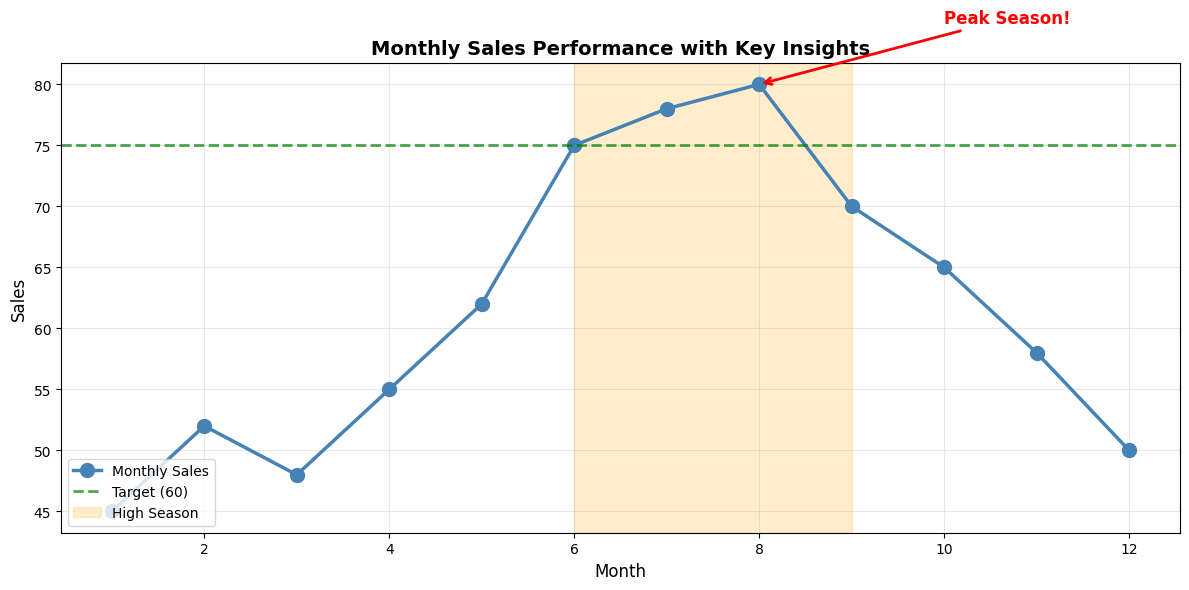

In [23]:
# Membuat figure dengan ukuran 12 inci lebar x 6 inci tinggi
plt.figure(figsize=(12, 6))

# Membuat line plot (plot garis) untuk data penjualan bulanan
plt.plot(
    x, y,                         # Data sumbu X dan Y
    marker='o',                   # Bentuk marker: lingkaran
    linewidth=2.5,                # Ketebalan garis = 2.5 point
    markersize=10,                # Ukuran marker = 10 point
    color='steelblue',            # Warna garis: biru baja
    label='Monthly Sales'         # Label untuk legend
)

# ========== 1. ARROW ANNOTATION (ANOTASI PANAH) UNTUK PUNCAK ==========
# annotate() = menambahkan teks dengan panah yang menunjuk ke titik tertentu
plt.annotate(
    'Peak Season!',               # Teks anotasi yang akan ditampilkan
    xy=(8, 80),                   # Titik yang dituju panah (x=8, y=80) - puncak penjualan
    xytext=(10, 85),              # Posisi teks ditempatkan (x=10, y=85) - di kanan agak atas
    arrowprops=dict(              # Properti panah penghubung
        arrowstyle='->',          # Bentuk panah: tanda panah satu arah
        color='red',              # Warna panah: merah
        lw=2                      # Line width (ketebalan) = 2 point
    ),
    fontsize=12,                  # Ukuran font teks = 12 point
    fontweight='bold',            # Tebal (bold)
    color='red'                   # Warna teks: merah
)

# ========== 2. HORIZONTAL TARGET LINE (GARIS TARGET HORIZONTAL) ==========
# axhline() = menambahkan garis horizontal pada nilai y tertentu
plt.axhline(
    y=75,                         # Posisi garis pada sumbu Y = 75
    color='green',                # Warna garis: hijau
    linestyle='--',               # Gaya garis: putus-putus (dashed)
    linewidth=2,                  # Ketebalan garis = 2 point
    alpha=0.7,                    # Transparansi (70% solid, 30% tembus)
    label='Target (60)'           # Label untuk legend
)

# ========== 3. SHADED REGION FOR HIGH SEASON (AREA ARSIRAN UNTUK MUSIM PUNCAK) ==========
# axvspan() = menambahkan area vertikal yang diarsir pada rentang x tertentu
plt.axvspan(
    6,                            # Batas awal arsiran (x = 6, bulan Juni)
    9,                            # Batas akhir arsiran (x = 9, bulan September)
    alpha=0.2,                    # Transparansi (20% solid, 80% tembus - sangat tipis)
    color='orange',               # Warna arsiran: oranye
    label='High Season'           # Label untuk legend
)

# ========== PENGATURAN JUDUL DAN LABEL ==========
# Memberi judul utama plot
plt.title('Monthly Sales Performance with Key Insights', fontsize=14, fontweight='bold')

# Memberi label sumbu X dengan ukuran font 12
plt.xlabel('Month', fontsize=12)

# Memberi label sumbu Y dengan ukuran font 12
plt.ylabel('Sales', fontsize=12)

# Menampilkan legend di pojok kiri bawah
plt.legend(loc='lower left')

# Menampilkan grid (garis bantu) dengan transparansi 30%
plt.grid(True, alpha=0.3)

# Mengatur layout agar elemen tidak terpotong
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

## Task 2c: Custom Spines (Clean Chart)

**Goal:** Create a modern, clean chart by customizing spines.

**Spine customization:**
- Remove top and right spines (less cluttered)
- Gray out remaining spines (subtle)
- Remove tick marks for minimal look

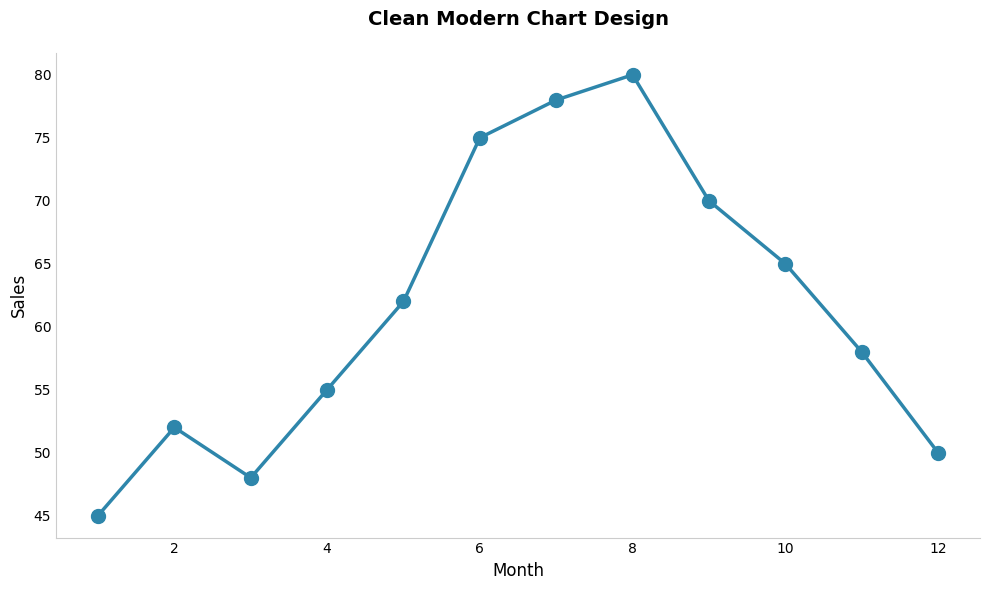

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, marker='o', linewidth=2.5, markersize=10, color='#2E86AB')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Make left and bottom spines gray
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Remove tick marks
ax.tick_params(axis='both', length=0)

# Add title with padding
ax.set_title('Clean Modern Chart Design', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Sales', fontsize=12)

plt.tight_layout()
plt.show()

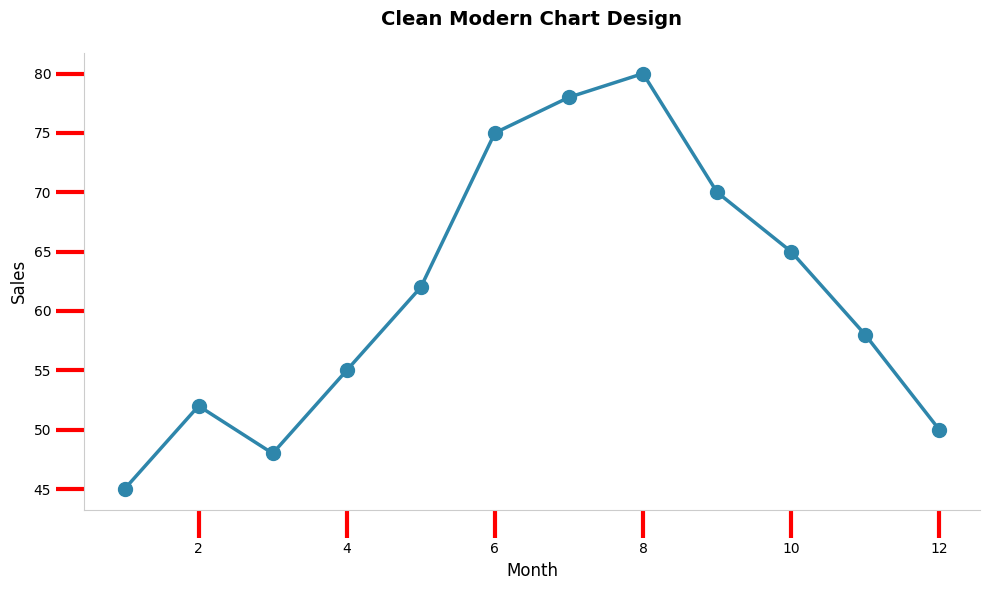

In [25]:
# Membuat figure dan axes dengan ukuran 10 inci lebar x 6 inci tinggi
fig, ax = plt.subplots(figsize=(10, 6))

# Membuat line plot (plot garis) dengan data x dan y
ax.plot(
    x, y,                         # Data sumbu X dan Y
    marker='o',                   # Bentuk marker: lingkaran (circle)
    linewidth=2.5,                # Ketebalan garis = 2.5 point
    markersize=10,                # Ukuran marker = 10 point
    color='#2E86AB'               # Warna garis dan marker: biru kebiruan
)

# ========== PENGATURAN SPINES (GARIS TEPI) ==========
# Menghilangkan spine (garis tepi) bagian atas (top)
ax.spines['top'].set_visible(False)

# Menghilangkan spine (garis tepi) bagian kanan (right)
ax.spines['right'].set_visible(False)

# Mengubah warna spine kiri (left) menjadi abu-abu terang (#CCCCCC)
ax.spines['left'].set_color('#CCCCCC')

# Mengubah warna spine bawah (bottom) menjadi abu-abu terang (#CCCCCC)
ax.spines['bottom'].set_color('#CCCCCC')

# ========== PENGATURAN TICK MARKS (GARIS PENANDA SUMBU) ==========
# Parameter tick_params yang sedang dalam mode komentar (tidak aktif)
# ax.tick_params(axis='both', length=0)  # length=0 = tanpa tick marks

# Pengaturan tick marks yang AKTIF (tidak dikoment)
ax.tick_params(
    axis='both',                  # Berlaku untuk sumbu X dan Y
    length=20,                    # Panjang tick mark = 20 point (cukup panjang)
    width=3,                      # Ketebalan tick mark = 3 point (lebih tebal dari default)
    color='red',                  # Warna tick marks = merah (kontras untuk debugging)
    direction='out'               # Arah tick marks ke LUAR dari area plot
)

# ========== PENGATURAN JUDUL DAN LABEL ==========
# Memberi judul dengan padding (jarak) 20 point dari plot
ax.set_title('Clean Modern Chart Design', fontsize=14, fontweight='bold', pad=20)

# Memberi label sumbu X dengan ukuran font 12
ax.set_xlabel('Month', fontsize=12)

# Memberi label sumbu Y dengan ukuran font 12
ax.set_ylabel('Sales', fontsize=12)

# Mengatur layout agar elemen tidak terpotong
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

---

# Part 3: Discrete & Continuous Colors 🌈

**Goal:** Choose and apply appropriate color palettes for different data types

**Color palette types:**
- **Categorical/Discrete:** For unordered categories (species, brands)
- **Sequential:** For ordered data with low-to-high progression
- **Diverging:** For data with a meaningful midpoint (correlations, temperature anomalies)

## Task 3a: Explore Color Palettes

**Goal:** Visualize different seaborn color palettes.

**When to use each:**
- **Set2/tab10:** Categorical data (no order)
- **Blues/Greens:** Sequential data (0-100, low-high)
- **RdBu/coolwarm:** Diverging data (-1 to +1, hot-cold)
- **colorblind:** Accessibility (10% of males have color blindness)

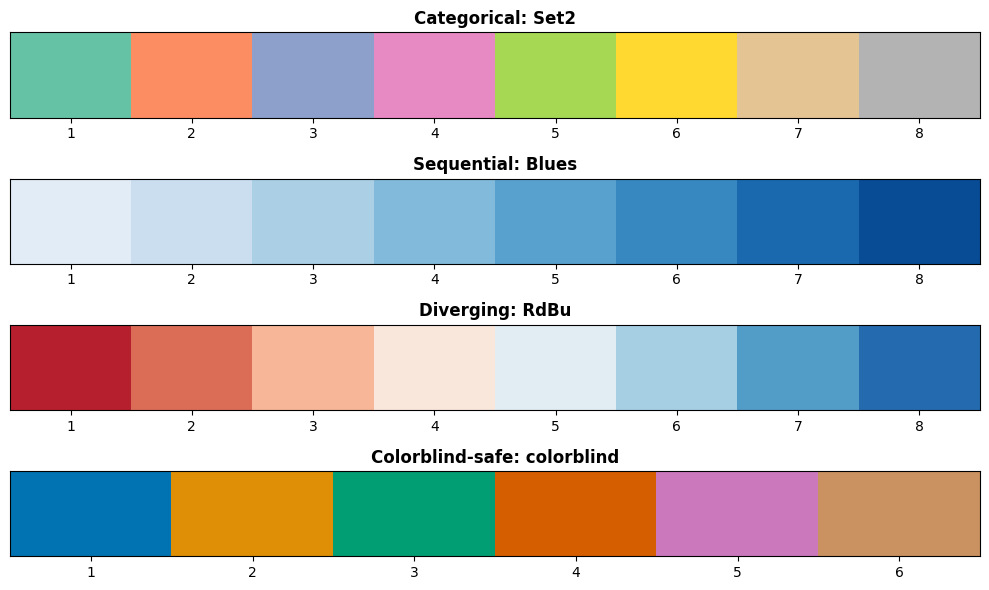

In [26]:
fig, axes = plt.subplots(4, 1, figsize=(10, 6))  # 4 baris vertikal

palettes = [
    ('Set2', 8, 'Categorical'),
    ('Blues', 8, 'Sequential'),
    ('RdBu', 8, 'Diverging'),
    ('colorblind', 6, 'Colorblind-safe')
]

for ax, (palette, n_colors, label) in zip(axes, palettes):
    # 1. Ambil warna dari seaborn palette
    colors = sns.color_palette(palette, n_colors)
    # colors = [(0.4,0.5,0.6), (0.7,0.8,0.9), ...]

    # 2. Tampilkan sebagai gambar (array 1 baris x n kolom)
    ax.imshow([colors], aspect='auto')

    # 3. Set judul palette
    ax.set_title(f'{label}: {palette}', fontsize=12, fontweight='bold')

    # 4. Set tick di sumbu X (posisi setiap warna)
    ax.set_xticks(range(n_colors))          # [0,1,2,...,7]
    ax.set_xticklabels(range(1, n_colors + 1))  # ['1','2',...,'8']

    # 5. Hilangkan tick di sumbu Y (karena hanya 1 baris)
    ax.set_yticks([])  # [] = kosong, tidak ada tick
    ax.set_ylabel('')   # Kosongkan label sumbu Y

plt.tight_layout()
plt.show()

## Task 3b: Discrete Colors for Categories

**Dataset:** `penguins`

**Goal:** Create a scatter plot with discrete colors for species.

**Best practice:** Use categorical palettes (Set2, tab10, colorblind) for unordered categories

In [27]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


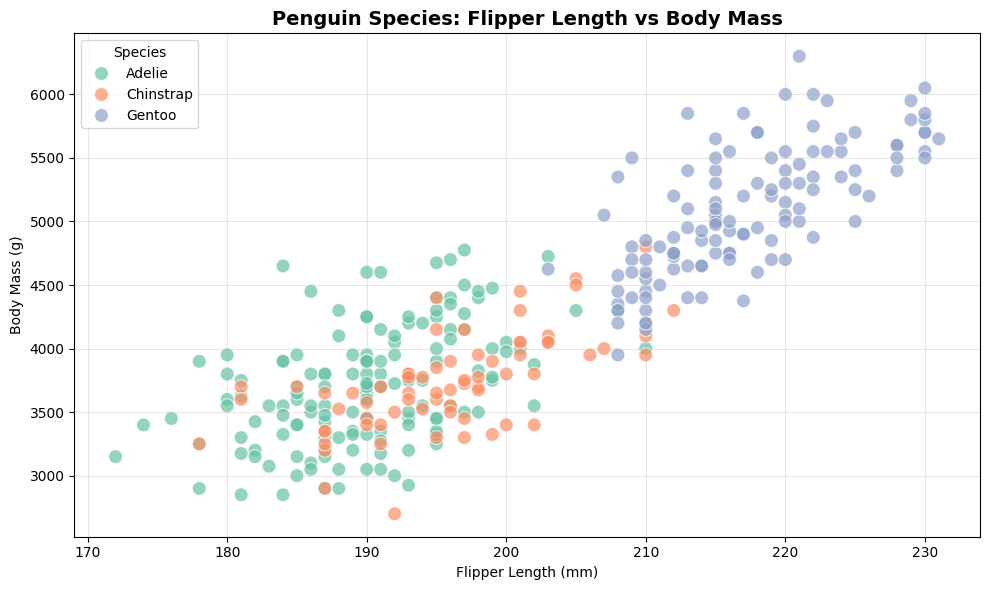

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
                hue='species', palette='Set2', s=100, alpha=0.7)
plt.title('Penguin Species: Flipper Length vs Body Mass', fontsize=14, fontweight='bold')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(title='Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

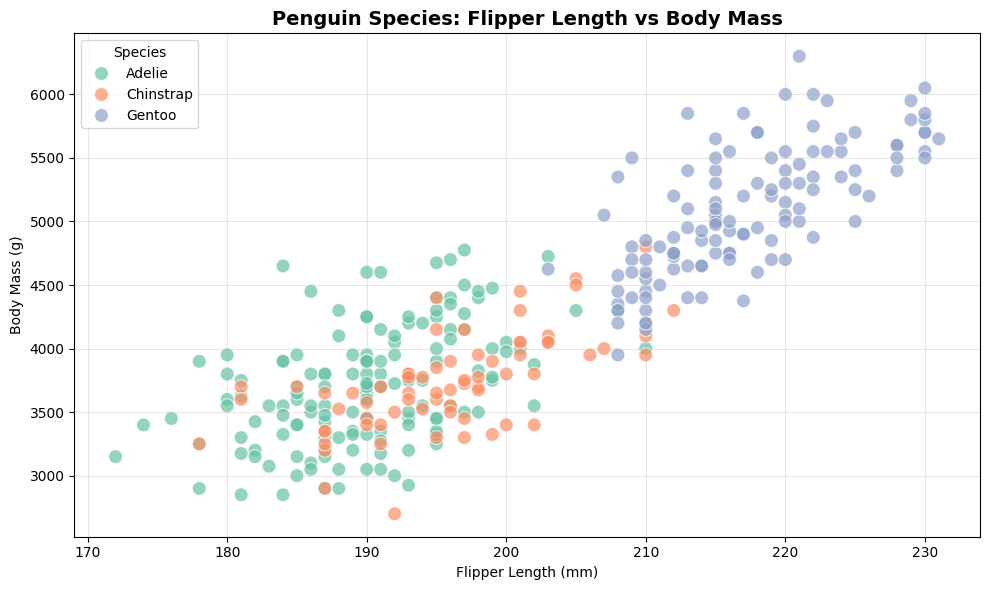

In [29]:
# Membuat figure dengan ukuran 10 inci lebar x 6 inci tinggi
plt.figure(figsize=(10, 6))

# Membuat scatter plot menggunakan seaborn
sns.scatterplot(
    data=penguins,                    # Dataset penguins dari seaborn
    x='flipper_length_mm',            # Sumbu X: panjang flipper (dalam mm)
    y='body_mass_g',                  # Sumbu Y: massa tubuh (dalam gram)
    hue='species',                    # Membedakan spesies berdasarkan warna
    palette='Set2',                   # Palet warna 'Set2' (soft, colorblind-friendly)
    s=100,                            # Ukuran marker (titik) = 100 point
    alpha=0.7                         # Transparansi (0.7 = 70% solid, 30% tembus)
)

# Memberi judul plot dengan ukuran font 14 dan tebal
plt.title('Penguin Species: Flipper Length vs Body Mass', fontsize=14, fontweight='bold')

# Memberi label sumbu X
plt.xlabel('Flipper Length (mm)')

# Memberi label sumbu Y
plt.ylabel('Body Mass (g)')

# Menampilkan legend (keterangan) dengan judul 'Species'
plt.legend(title='Species')

# Menampilkan grid (garis bantu) dengan transparansi 30%
plt.grid(True, alpha=0.3)

# Mengatur layout agar elemen plot tidak terpotong atau tumpang tindih
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

## Task 3c: Continuous Colors for Heatmap

**Dataset:** `tips` (correlation matrix)

**Goal:** Create a correlation heatmap with appropriate diverging colors.

**Why diverging colors?**
- Correlations range from -1 (negative) to +1 (positive)
- Midpoint (0 = no correlation) should be neutral
- Use `center=0` to align the color scale

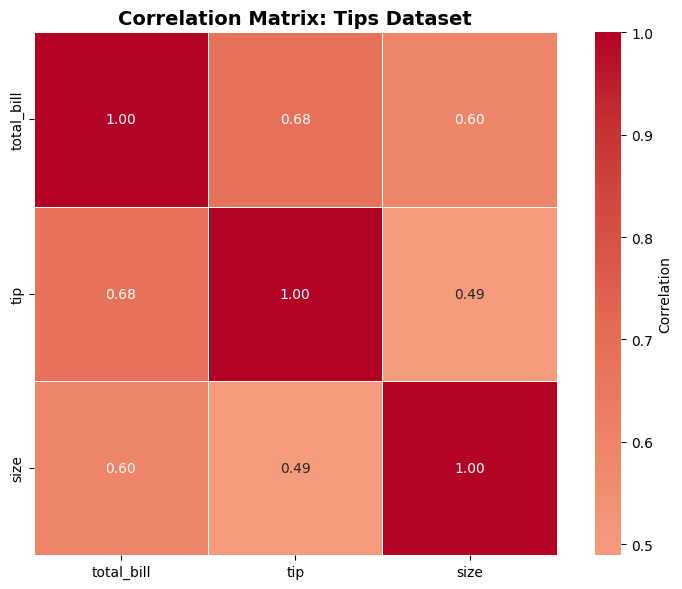

In [30]:
plt.figure(figsize=(8, 6))
corr = tips.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix: Tips Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

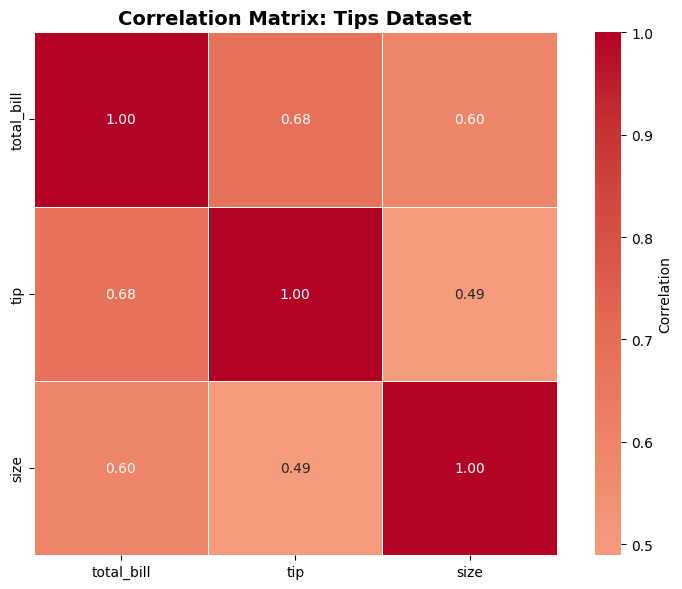

In [31]:
# Membuat figure dengan ukuran 8 inci (lebar) x 6 inci (tinggi)
plt.figure(figsize=(8, 6))

# STEP 1: Menghitung matriks korelasi
# select_dtypes(include='number') = hanya mengambil kolom bertipe numerik (bukan kategori seperti 'day', 'sex')
# .corr() = menghitung korelasi Pearson antar kolom (nilai -1 sampai +1)
corr = tips.select_dtypes(include='number').corr()

# STEP 2: Membuat heatmap dari matriks korelasi
sns.heatmap(
    corr,                       # Data: matriks korelasi (DataFrame)

    # ========== PARAMETER ANNOTASI ==========
    annot=True,                 # Menampilkan NILAI KORELASI di dalam kotak
                                # True = tampilkan angka, False = tanpa angka

    fmt='.2f',                  # Format angka (hanya berlaku jika annot=True)
                                # '.2f' = 2 angka di belakang koma (contoh: 0.75)
                                # Opsi lain: '.1f' (1 desimal), '.3f' (3 desimal), '.0f' (tanpa desimal)
                                # 'd' = integer, '.2%' = persentase

    # ========== PARAMETER WARNA ==========
    cmap='coolwarm',            # Color map (peta warna) untuk heatmap
                                # 'coolwarm': biru (korelasi negatif) → putih (0) → merah (korelasi positif)
                                # Opsi lain: 'viridis', 'plasma', 'RdBu', 'RdYlGn', 'Blues'

    center=0,                   # Titik tengah colormap (nilai yang dianggap 'netral')
                                # center=0 berarti nilai 0 akan berwarna putih (tidak berkorelasi)
                                # Korelasi negatif → biru, positif → merah

    # ========== PARAMETER VISUAL ==========
    square=True,                # Membuat setiap kotak berbentuk PERSEGI (bukan persegi panjang)
                                # True = kotak berbentuk bujur sangkar
                                # False = kotak memanjang sesuai figure

    linewidths=0.5,             # Ketebalan garis PISAH antar kotak (dalam point)
                                # 0.5 = garis tipis di antara setiap sel
                                # 0 = tanpa garis pemisah
                                # >0 = semakin tebal garis pemisah

    # ========== PARAMETER COLORBAR ==========
    cbar_kws={'label': 'Correlation'}  # Dictionary untuk mengatur colorbar (legend warna)
                                       # 'label': teks label di samping colorbar
                                       # Bisa ditambah: {'label': 'Correlation', 'shrink': 0.8, 'pad': 0.05}
)

# STEP 3: Memberi judul heatmap
plt.title('Correlation Matrix: Tips Dataset', fontsize=14, fontweight='bold')

# STEP 4: Mengatur layout agar tidak terpotong
plt.tight_layout()

# STEP 5: Menampilkan hasil
plt.show()

## Task 3d: Custom Color Palette

**Goal:** Create a scatter plot with your own custom colors.

**How to create custom palettes:**
- Use hex codes: `'#1abc9c'`, `'#3498db'`, etc.
- Use RGB tuples: `(0.2, 0.4, 0.6)`
- Mix predefined colors: `'red'`, `'blue'`, etc.

**Tip:** Use tools like coolors.co or colorhunt.co for palette inspiration!

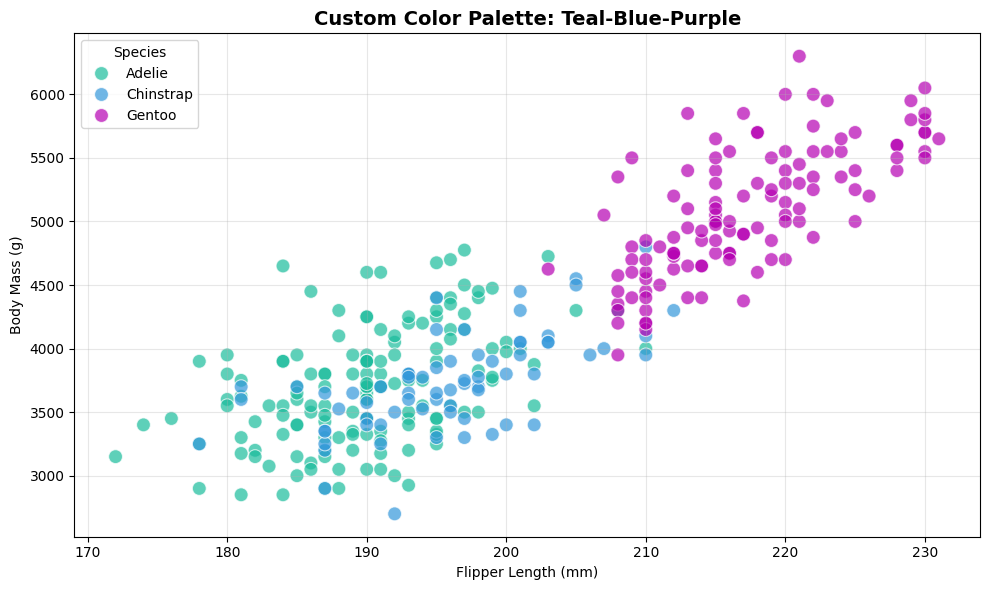

In [32]:
# Custom palette: Modern teal-blue-purple
custom_palette = ['#1abc9c', '#3498db', '#B500B2']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
                hue='species', palette=custom_palette, s=100, alpha=0.7)
plt.title('Custom Color Palette: Teal-Blue-Purple', fontsize=14, fontweight='bold')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(title='Species')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

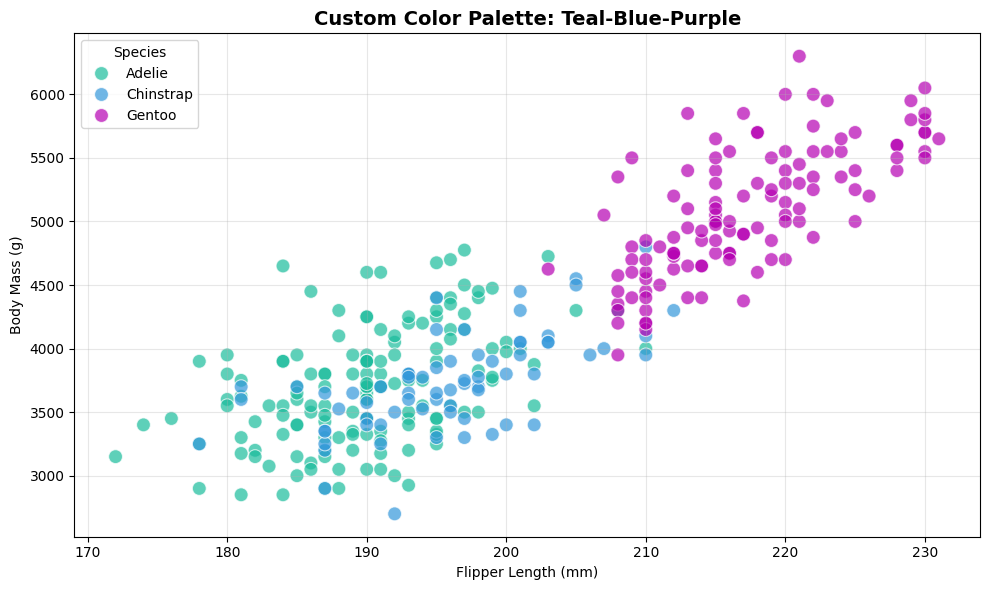

In [33]:
# Custom palette: Modern teal-blue-purple
# Membuat palet warna kustom dengan 3 warna:
# '#1abc9c' = Teal (hijau kebiruan) - untuk satu spesies
# '#3498db' = Biru terang - untuk spesies kedua
# '#B500B2' = Ungu keunguan - untuk spesies ketiga
custom_palette = ['#1abc9c', '#3498db', '#B500B2']

# Membuat figure dengan ukuran 10 inci lebar x 6 inci tinggi
plt.figure(figsize=(10, 6))

# Membuat scatter plot menggunakan seaborn
sns.scatterplot(
    data=penguins,                    # Dataset penguins
    x='flipper_length_mm',            # Sumbu X: panjang flipper (mm)
    y='body_mass_g',                  # Sumbu Y: massa tubuh (gram)
    hue='species',                    # Membedakan spesies berdasarkan warna
    palette=custom_palette,           # Menggunakan palet warna kustom (Teal-Biru-Ungu)
    s=100,                            # Ukuran marker (titik) = 100 point
    alpha=0.7                         # Transparansi (70% tidak transparan, 30% tembus)
)

# Memberi judul plot
plt.title('Custom Color Palette: Teal-Blue-Purple', fontsize=14, fontweight='bold')

# Memberi label sumbu X
plt.xlabel('Flipper Length (mm)')

# Memberi label sumbu Y
plt.ylabel('Body Mass (g)')

# Menampilkan legend (keterangan) dengan judul 'Species'
plt.legend(title='Species')

# Menampilkan grid (garis bantu) dengan transparansi 30%
plt.grid(True, alpha=0.3)

# Mengatur layout agar elemen tidak terpotong
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

---

# Part 4: Facet with Wraps and Grids 📊

**Goal:** Create small multiples to compare subsets of data

**Faceting = Creating multiple subplots for each category**

**Benefits:**
- Compare patterns across groups easily
- Avoid overplotting (too many colors/categories in one plot)
- Professional, publication-ready layouts

## Task 4a: Basic FacetGrid

**Dataset:** `tips`

**Goal:** Create a FacetGrid showing scatter plots of total_bill vs tip.

**FacetGrid structure:**
- `col=` creates columns for each category
- `row=` creates rows for each category
- `g.map()` applies the same plot to each facet

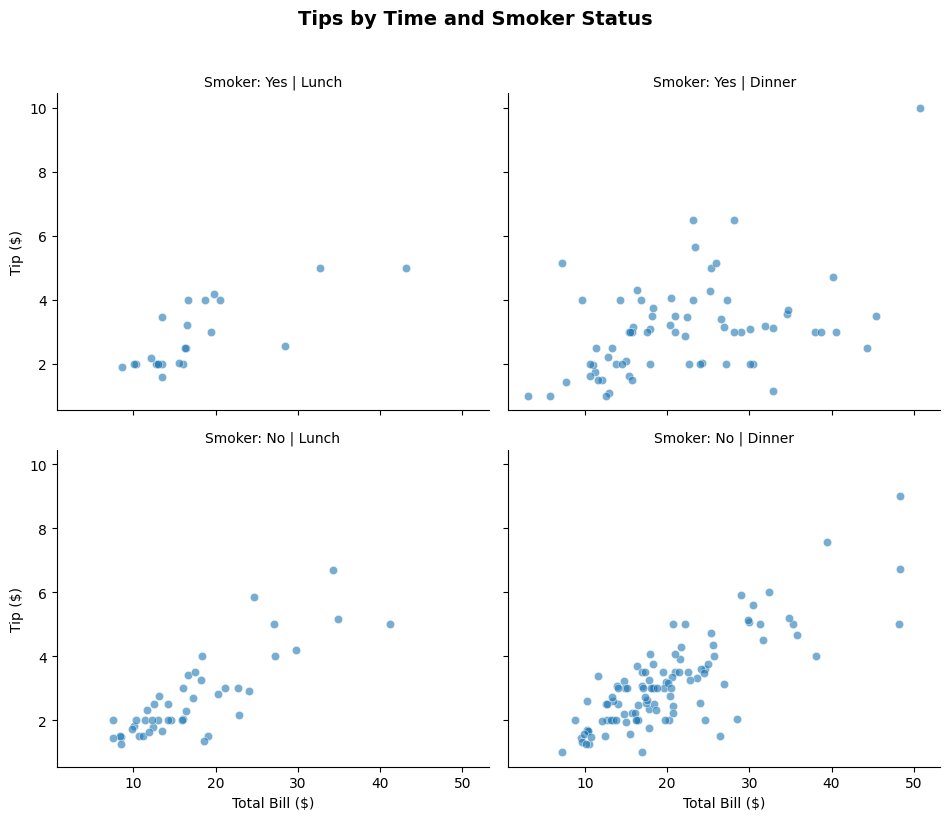

In [34]:
g = sns.FacetGrid(tips, col='time', row='smoker', height=4, aspect=1.2)
g.map(sns.scatterplot, 'total_bill', 'tip', alpha=0.6)
g.set_titles(col_template="{col_name}", row_template="Smoker: {row_name}")
g.set_axis_labels("Total Bill ($)", "Tip ($)")
g.fig.suptitle('Tips by Time and Smoker Status', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

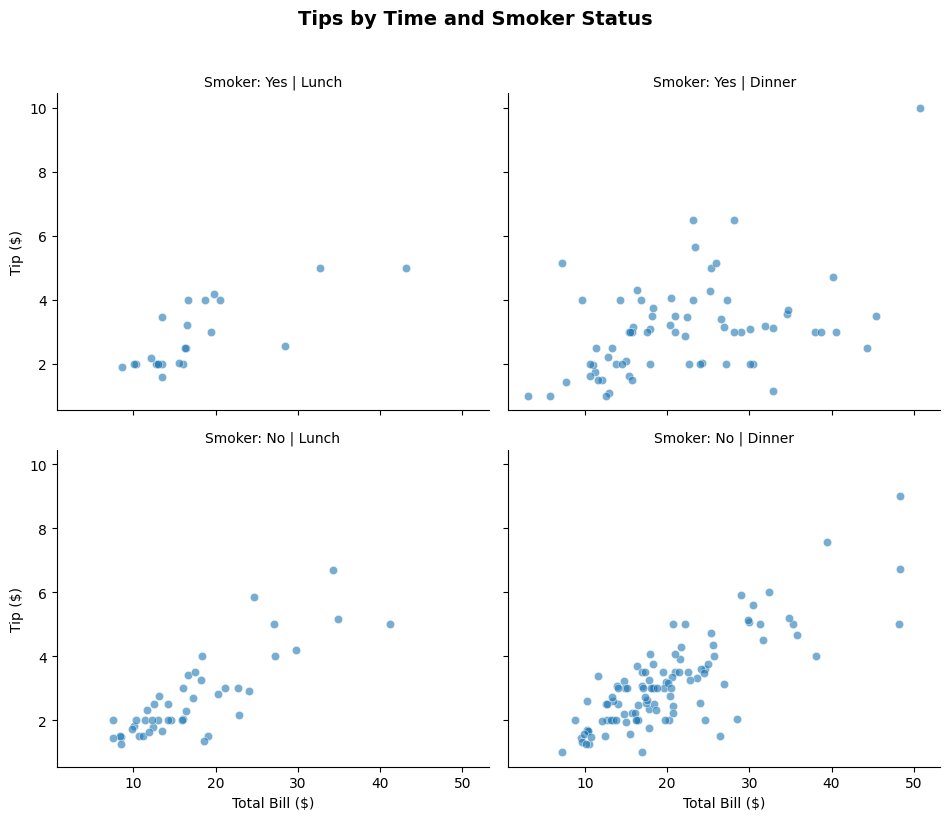

In [35]:
# STEP 1: Membuat grid facet (kisi-kisi subplot berdasarkan kategori)
# FacetGrid = membuat multiple plot berdasarkan kombinasi kolom kategori
g = sns.FacetGrid(
    data=tips,                    # Dataset yang digunakan

    col='time',                   # Membuat kolom grid berdasarkan kategori 'time' (Lunch/Dinner)
                                  # Akan tampil sebagai plot terpisah secara HORIZONTAL

    row='smoker',                 # Membuat baris grid berdasarkan kategori 'smoker' (Yes/No)
                                  # Akan tampil sebagai plot terpisah secara VERTIKAL

    height=4,                     # Tinggi setiap subplot (dalam inci)
                                  # height=4 berarti setiap plot tinggi 4 inci

    aspect=1.2                    # Rasio aspek (lebar/tinggi)
                                  # aspect=1.2 berarti lebar = 4 × 1.2 = 4.8 inci
)

# STEP 2: Memetakan plot ke setiap facet (subplot)
# .map() = menerapkan fungsi plot ke setiap sel dalam grid
g.map(
    sns.scatterplot,              # Jenis plot yang akan digambar (scatter plot)
    'total_bill',                 # Kolom untuk sumbu X (total tagihan)
    'tip',                        # Kolom untuk sumbu Y (tip/uang tip)
    alpha=0.6                     # Transparansi titik (0 = transparan, 1 = solid)
                                  # alpha=0.6 membuat titik agak transparan agar tidak saling menutupi
)

# STEP 3: Mengatur judul untuk setiap subplot
g.set_titles(
    col_template="{col_name}",    # Template judul untuk kolom (time)
                                  # {col_name} akan diganti 'Lunch' atau 'Dinner'

    row_template="Smoker: {row_name}"  # Template judul untuk baris (smoker)
                                  # {row_name} akan diganti 'Yes' atau 'No'
                                  # Hasil: "Smoker: Yes" atau "Smoker: No"
)

# STEP 4: Memberi label sumbu X dan Y (diterapkan ke semua subplot)
g.set_axis_labels(
    "Total Bill ($)",             # Label untuk sumbu X
    "Tip ($)"                     # Label untuk sumbu Y
)

# STEP 5: Memberi judul utama untuk seluruh figure
g.fig.suptitle(
    'Tips by Time and Smoker Status',  # Teks judul utama
    y=1.02,                            # Posisi vertikal judul (sedikit di atas)
                                       # y=1.02 = 2% di atas batas normal
    fontsize=14,                       # Ukuran font judul
    fontweight='bold'                  # Tebal (bold)
)

# STEP 6: Mengatur layout agar tidak terpotong
plt.tight_layout()

# STEP 7: Menampilkan hasil
plt.show()

## Task 4b: Facet with col_wrap

**Dataset:** `tips`

**Goal:** Create histograms of total_bill faceted by day with wrapping.

**Why use `col_wrap`?**
- When you have many categories (e.g., 7 days of week)
- Prevents one very wide row
- `col_wrap=2` means max 2 plots per row

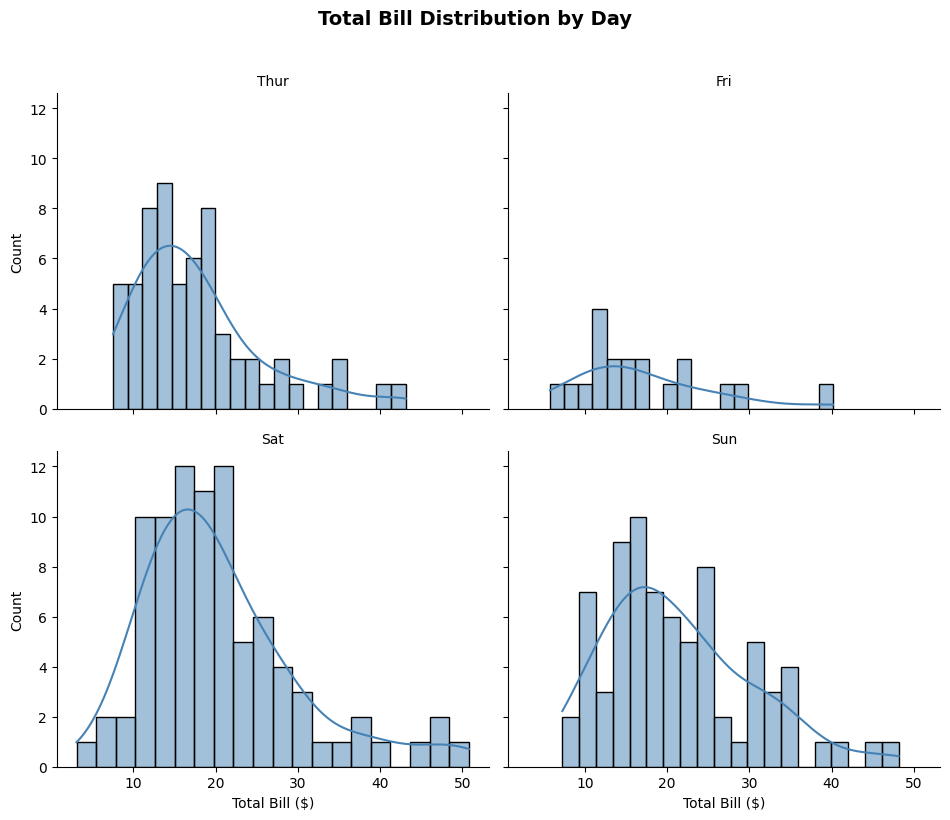

In [36]:
g = sns.FacetGrid(tips, col='day', col_wrap=2, height=4, aspect=1.2)
g.map(sns.histplot, 'total_bill', kde=True, bins=20, color='steelblue')
g.set_titles("{col_name}")
g.set_axis_labels("Total Bill ($)", "Count")
g.fig.suptitle('Total Bill Distribution by Day', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

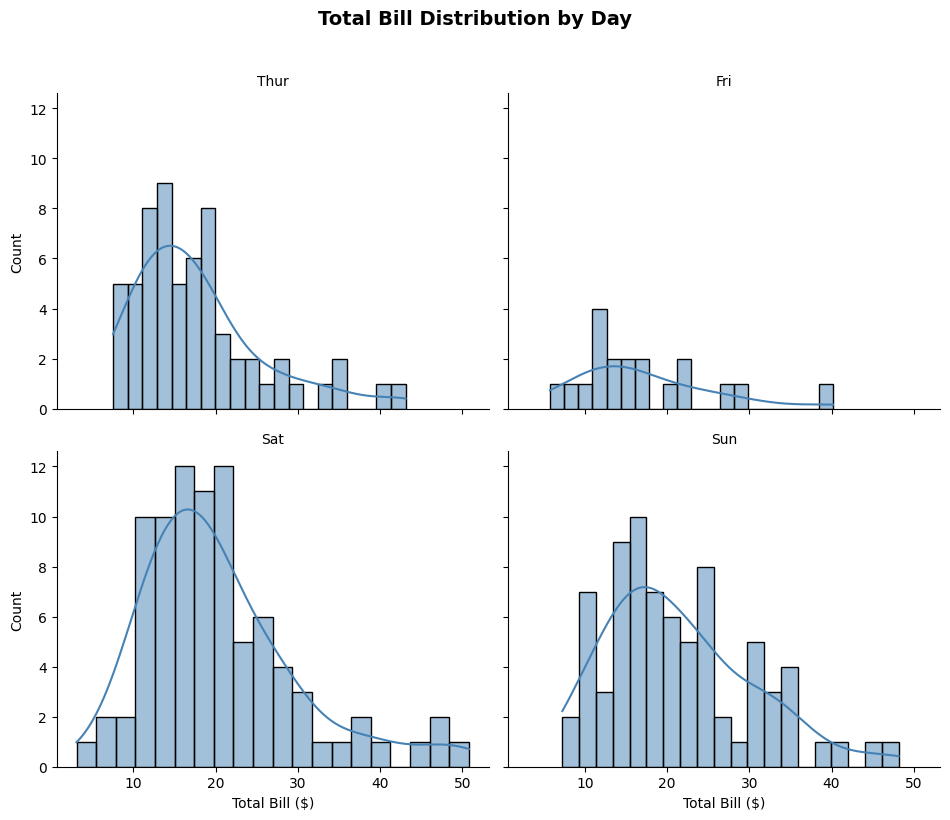

In [37]:
# STEP 1: Membuat grid facet (kisi-kisi subplot) untuk membandingkan distribusi per hari
# col='day' = membuat subplot berdasarkan kategori 'day' (Thur, Fri, Sat, Sun)
g = sns.FacetGrid(
    data=tips,                    # Dataset yang digunakan

    col='day',                    # Membuat kolom grid berdasarkan kategori 'day' (Hari)
                                  # Akan tampil sebagai plot terpisah untuk setiap hari

    col_wrap=2,                   # Membungkus kolom setelah 2 plot (membuat baris baru)
                                  # Karena ada 4 hari, akan disusun 2 kolom × 2 baris
                                  # col_wrap=2 artinya: maksimal 2 plot per baris
                                  # Tanpa col_wrap: 4 plot dalam 1 baris (terlalu lebar)

    height=4,                     # Tinggi setiap subplot (dalam inci)
                                  # height=4 berarti setiap plot tinggi 4 inci

    aspect=1.2                    # Rasio aspek (lebar/tinggi)
                                  # aspect=1.2 berarti lebar = 4 × 1.2 = 4.8 inci
)

# STEP 2: Memetakan histogram ke setiap facet (subplot)
# .map() = menerapkan fungsi plot ke setiap sel dalam grid
g.map(
    sns.histplot,                 # Jenis plot: histogram (distribusi frekuensi)
    'total_bill',                 # Kolom untuk sumbu X (total tagihan)

    kde=True,                     # Kernel Density Estimation = garis kepadatan
                                  # True = tambahkan garis halus yang menunjukkan bentuk distribusi
                                  # False = hanya batang histogram saja

    bins=20,                      # Jumlah interval (batang) dalam histogram
                                  # bins=20 = data dibagi menjadi 20 kelompok/rentang
                                  # Semakin besar bins, semakin detail distribusinya

    color='steelblue'             # Warna batang histogram (biru baja)
                                  # Semua subplot menggunakan warna yang sama
)

# STEP 3: Mengatur judul untuk setiap subplot
g.set_titles(
    "{col_name}"                  # Template judul untuk kolom (hari)
                                  # {col_name} akan diganti 'Thur', 'Fri', 'Sat', 'Sun'
                                  # Hasil: "Thur", "Fri", "Sat", "Sun"
)

# STEP 4: Memberi label sumbu X dan Y (diterapkan ke semua subplot)
g.set_axis_labels(
    "Total Bill ($)",             # Label untuk sumbu X (total tagihan dalam dolar)
    "Count"                       # Label untuk sumbu Y (frekuensi/jumlah pelanggan)
)

# STEP 5: Memberi judul utama untuk seluruh figure
g.fig.suptitle(
    'Total Bill Distribution by Day',  # Teks judul utama
    y=1.02,                            # Posisi vertikal judul (2% di atas normal)
    fontsize=14,                       # Ukuran font judul
    fontweight='bold'                  # Tebal (bold)
)

# STEP 6: Mengatur layout agar tidak terpotong
plt.tight_layout()

# STEP 7: Menampilkan hasil
plt.show()

## Task 4c: catplot with Built-in Faceting

**Dataset:** `tips`

**Goal:** Create box plots faceted by time.

**`catplot` advantages:**
- Combines FacetGrid + categorical plot in one function
- Supports `kind=` parameter: 'box', 'violin', 'bar', 'count', etc.
- Automatically handles legends and labels

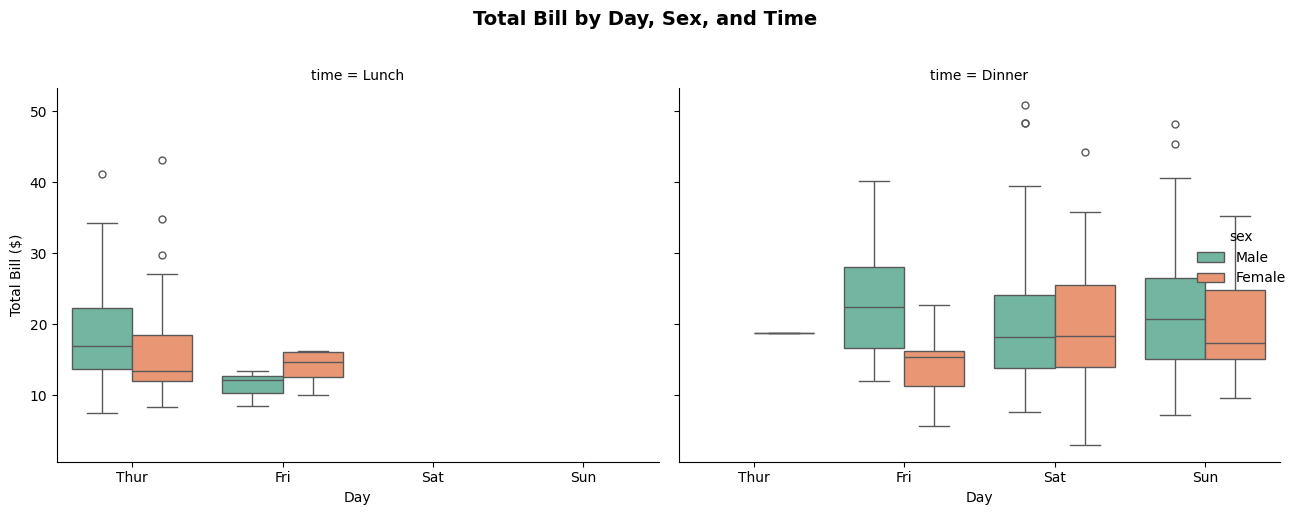

In [38]:
g = sns.catplot(data=tips, x='day', y='total_bill', hue='sex',
                col='time', kind='box', palette='Set2',
                height=5, aspect=1.2)
g.set_axis_labels("Day", "Total Bill ($)")
g.fig.suptitle('Total Bill by Day, Sex, and Time', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

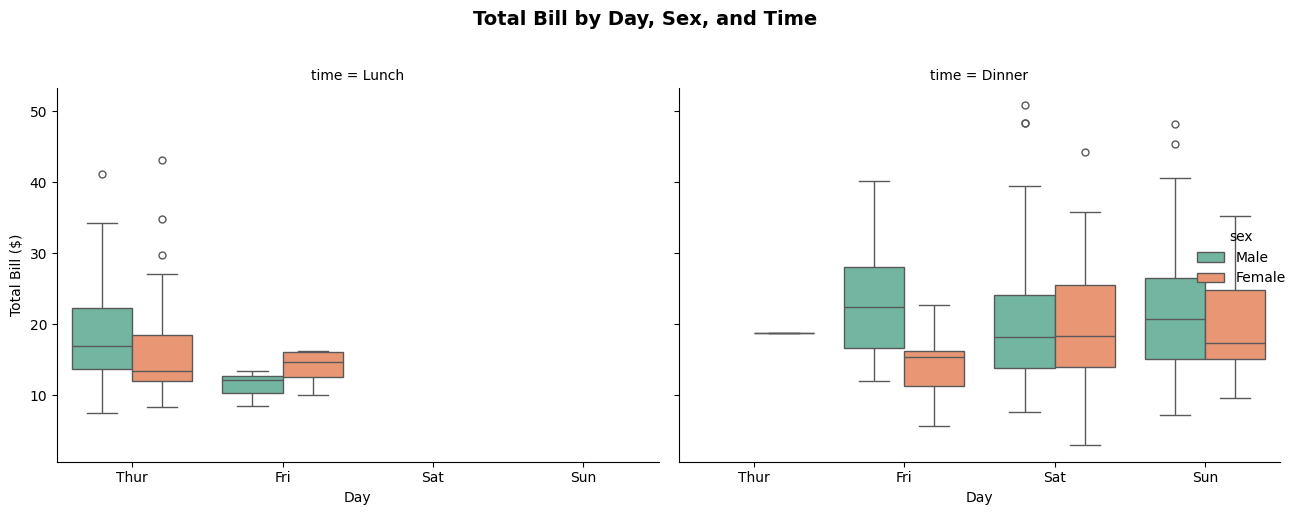

In [39]:
# STEP 1: Membuat plot kategorikal menggunakan catplot
# catplot = categorical plot (plot untuk data kategorikal)
# Ini adalah figure-level function (membuat figure secara otomatis)
g = sns.catplot(
    data=tips,                    # Dataset yang digunakan

    x='day',                      # Sumbu X: kategori 'day' (Thur, Fri, Sat, Sun)
                                  # Akan muncul sebagai kelompok di sumbu horizontal

    y='total_bill',               # Sumbu Y: nilai numerik 'total_bill' (total tagihan)
                                  # Nilai ini akan diplot sebagai box plot

    hue='sex',                    # Mengelompokkan berdasarkan warna (gender)
                                  # 'sex' memiliki 2 nilai: Male (Laki-laki) dan Female (Perempuan)
                                  # Akan muncul dengan warna berbeda dalam satu kelompok hari

    col='time',                   # Membuat kolom grid berdasarkan kategori 'time'
                                  # 'time' memiliki 2 nilai: Lunch (Makan Siang) dan Dinner (Makan Malam)
                                  # Akan membuat 2 subplot berdampingan

    kind='box',                   # Jenis plot: 'box' = Box Plot
                                  # Opsi lain: 'violin', 'bar', 'point', 'strip', 'swarm'

    palette='Set2',               # Palet warna untuk hue (perbedaan gender)
                                  # 'Set2' = palet warna yang soft dan colorblind-friendly

    height=5,                     # Tinggi setiap subplot (dalam inci)
                                  # height=5 berarti setiap plot tinggi 5 inci

    aspect=1.2                    # Rasio aspek (lebar/tinggi) setiap subplot
                                  # aspect=1.2 berarti lebar = 5 × 1.2 = 6 inci
)

# STEP 2: Memberi label sumbu X dan Y (diterapkan ke semua subplot)
g.set_axis_labels(
    "Day",                        # Label untuk sumbu X (Hari)
    "Total Bill ($)"              # Label untuk sumbu Y (Total tagihan dalam dolar)
)

# STEP 3: Memberi judul utama untuk seluruh figure
g.fig.suptitle(
    'Total Bill by Day, Sex, and Time',  # Teks judul utama
    y=1.02,                              # Posisi vertikal judul (2% di atas normal)
    fontsize=14,                         # Ukuran font judul
    fontweight='bold'                    # Tebal (bold)
)

# STEP 4: Mengatur layout agar tidak terpotong
plt.tight_layout()

# STEP 5: Menampilkan hasil
plt.show()

## Task 4d: Plotly Express Faceting

**Dataset:** `tips`

**Goal:** Create an interactive faceted scatter plot with Plotly.

**Plotly advantages:**
- **Interactive** - Hover for details, zoom, pan
- **Easy sharing** - Export as HTML
- **Professional** - Publication-ready with minimal code

In [40]:
fig = px.scatter(tips, x='total_bill', y='tip', color='smoker',
                 facet_col='time', facet_row='sex',
                 hover_data=['day', 'size'],
                 title='Interactive Faceted Scatter: Tips Dataset',
                 labels={'total_bill': 'Total Bill ($)', 'tip': 'Tip ($)'})
fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.show()

In [41]:
# STEP 1: Membuat scatter plot interaktif menggunakan Plotly Express
# px = plotly.express (library untuk visualisasi interaktif)
# Berbeda dengan matplotlib/seaborn, plotly menghasilkan plot yang bisa di-zoom, hover, dan interaktif
fig = px.scatter(
    tips,                    # Dataset yang digunakan (tips dari seaborn)

    # ========== PARAMETER SUMBU ==========
    x='total_bill',               # Sumbu X: total tagihan (dalam dolar)
                                  # Semakin besar tagihan, semakin ke kanan posisinya

    y='tip',                      # Sumbu Y: tip/uang tip (dalam dolar)
                                  # Semakin besar tip, semakin ke atas posisinya

    # ========== PARAMETER WARNA DAN KATEGORI ==========
    color='smoker',               # Mewarnai titik berdasarkan status perokok
                                  # 'smoker' memiliki 2 nilai: Yes (Merokok) dan No (Tidak Merokok)
                                  # Akan muncul dengan warna berbeda secara otomatis

    # ========== PARAMETER FACET (GRID) ==========
    facet_col='time',             # Membuat kolom grid berdasarkan waktu makan
                                  # 'time' memiliki 2 nilai: Lunch (Makan Siang) dan Dinner (Makan Malam)
                                  # Akan membuat subplot secara HORIZONTAL

    facet_row='sex',              # Membuat baris grid berdasarkan gender
                                  # 'sex' memiliki 2 nilai: Male (Laki-laki) dan Female (Perempuan)
                                  # Akan membuat subplot secara VERTIKAL

    # ========== PARAMETER INTERAKTIF ==========
    hover_data=['day', 'size'],   # Data yang muncul saat cursor diarahkan ke titik
                                  # Selain menampilkan x dan y, juga tampilkan 'day' (hari) dan 'size' (jumlah orang)
                                  # Contoh hover: "total_bill=15.00, tip=3.00, day=Sat, size=2"

    # ========== PARAMETER JUDUL ==========
    title='Interactive Faceted Scatter: Tips Dataset',  # Judul utama plot

    # ========== PARAMETER LABEL ==========
    labels={                      # Mengganti nama label sumbu (lebih rapi)
        'total_bill': 'Total Bill ($)',  # Label sumbu X
        'tip': 'Tip ($)'                 # Label sumbu Y
    }
)

# STEP 2: Memperbarui tampilan marker (titik) pada scatter plot
fig.update_traces(
    marker=dict(                  # Dictionary pengaturan marker
        size=8,                   # Ukuran titik (default lebih kecil, ini diperbesar jadi 8)
                                  # Semakin besar angka, semakin besar titiknya

        opacity=0.7               # Transparansi titik (0 = transparan, 1 = solid)
                                  # opacity=0.7 = 70% tidak transparan (masih sedikit tembus pandang)
                                  # Berguna agar titik yang bertumpuk masih terlihat
    )
)

# STEP 3: Menampilkan plot interaktif
# Plot akan muncul di browser/notebook dengan kemampuan:
# - Hover: melihat detail data
# - Zoom: memperbesar area tertentu
# - Pan: geser plot
# - Download: simpan sebagai gambar
fig.show()

---

# 🏆 Bonus: Export High-Quality Figure

**Goal:** Create a publication-ready chart and export it in multiple formats.

**Export formats:**
- **PNG** (300 DPI) - Web, presentations, reports
- **PDF** - Publications, printing, LaTeX documents
- **SVG** - Vector format, editable in Illustrator/Inkscape

**Best practices:**
- Use `dpi=300` for print quality (web: 72-150 DPI)
- `bbox_inches='tight'` prevents label cutoff
- `facecolor='white'` ensures white background (important for transparency)

✅ Exported as:
  - penguin_analysis.png (300 DPI - for presentations)
  - penguin_analysis.pdf (vector - for publications)
  - penguin_analysis.svg (vector - for editing)


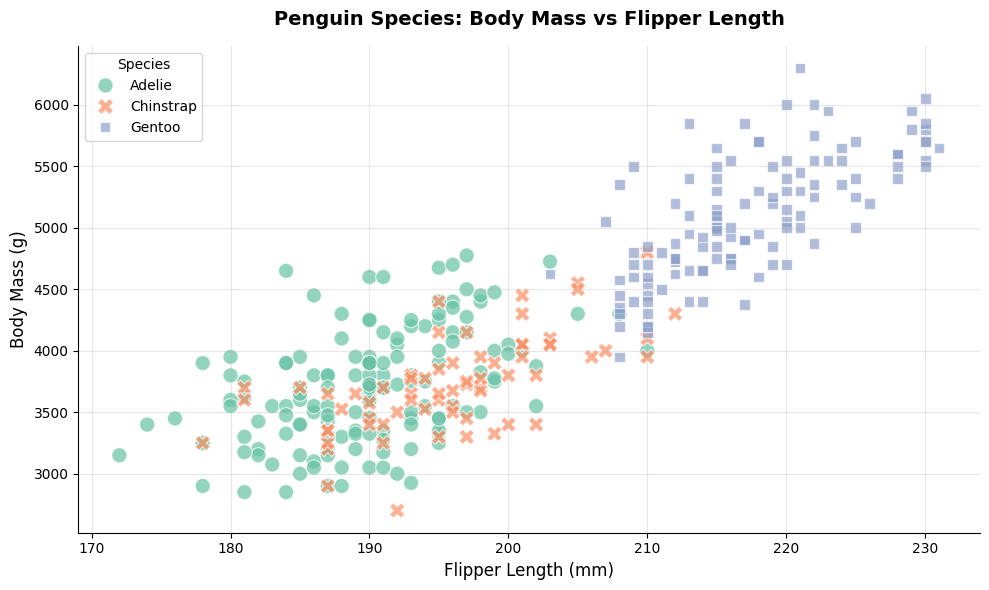

In [42]:
# Create a professional visualization
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g',
                hue='species', style='species', s=120, alpha=0.7,
                palette='Set2', ax=ax)

ax.set_title('Penguin Species: Body Mass vs Flipper Length',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Flipper Length (mm)', fontsize=12)
ax.set_ylabel('Body Mass (g)', fontsize=12)
ax.legend(title='Species', loc='upper left')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Export in multiple formats
fig.savefig('penguin_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig('penguin_analysis.pdf', bbox_inches='tight')
fig.savefig('penguin_analysis.svg', bbox_inches='tight')

print("✅ Exported as:")
print("  - penguin_analysis.png (300 DPI - for presentations)")
print("  - penguin_analysis.pdf (vector - for publications)")
print("  - penguin_analysis.svg (vector - for editing)")

plt.show()

✅ Exported as:
  - penguin_analysis.png (300 DPI - for presentations)
  - penguin_analysis.pdf (vector - for publications)
  - penguin_analysis.svg (vector - for editing)


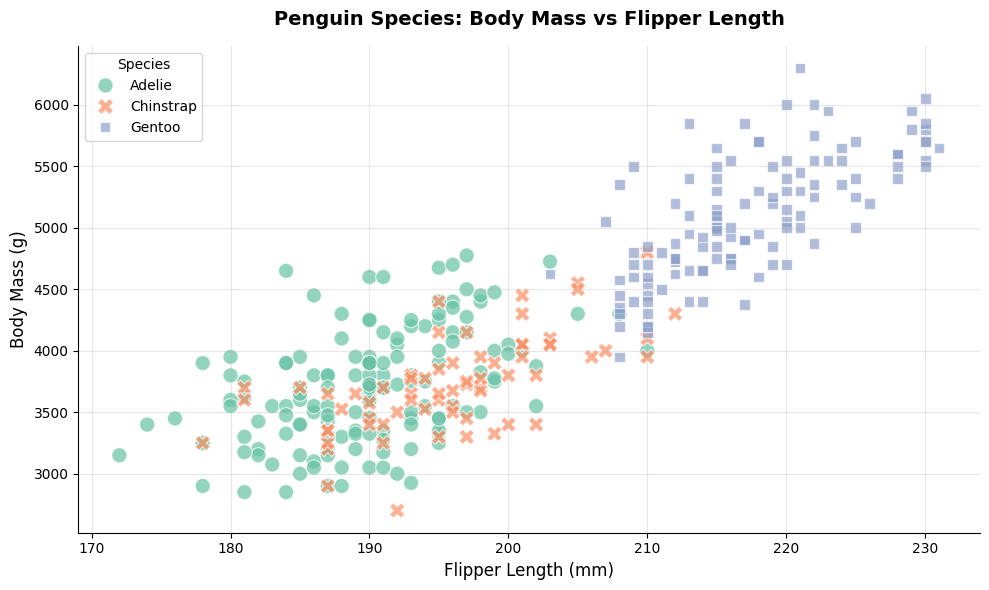

In [43]:
# Create a professional visualization
# Membuat figure dan axes dengan ukuran 10 inci lebar x 6 inci tinggi
fig, ax = plt.subplots(figsize=(10, 6))

# Membuat scatter plot menggunakan seaborn
sns.scatterplot(
    data=penguins,                    # Dataset penguins dari seaborn
    x='flipper_length_mm',            # Sumbu X: panjang flipper (mm)
    y='body_mass_g',                  # Sumbu Y: massa tubuh (gram)
    hue='species',                    # Warna berbeda untuk setiap spesies penguin
    style='species',                  # Bentuk marker berbeda untuk setiap spesies
    s=120,                            # Ukuran marker (default lebih kecil, 120 = cukup besar)
    alpha=0.7,                        # Transparansi (0 = transparan, 1 = solid)
    palette='Set2',                   # Palet warna yang soft dan colorblind-friendly
    ax=ax                             # Gunakan axes yang sudah dibuat
)

# Memberi judul plot
ax.set_title('Penguin Species: Body Mass vs Flipper Length',
             fontsize=14, fontweight='bold', pad=15)  # pad=15: jarak judul ke plot

# Memberi label sumbu X
ax.set_xlabel('Flipper Length (mm)', fontsize=12)

# Memberi label sumbu Y
ax.set_ylabel('Body Mass (g)', fontsize=12)

# Menampilkan legend (keterangan) dengan judul 'Species' di pojok kiri atas
ax.legend(title='Species', loc='upper left')

# Menampilkan grid (garis bantu) dengan transparansi 30%
ax.grid(True, alpha=0.3)

# Menghilangkan spine (garis tepi) bagian atas (top)
ax.spines['top'].set_visible(False)

# Menghilangkan spine (garis tepi) bagian kanan (right)
ax.spines['right'].set_visible(False)

# Mengatur layout agar elemen tidak terpotong
plt.tight_layout()

# ========== EKSPOR FILE DALAM 3 FORMAT ==========

# 1. EKSPOR SEBAGAI PNG (raster / pixel-based)
# dpi=300: resolusi 300 dot per inch (cetak/presentasi berkualitas)
# bbox_inches='tight': memotong margin putih berlebih
# facecolor='white': background putih (agar tidak transparan)
fig.savefig('penguin_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')

# 2. EKSPOR SEBAGAI PDF (vector / scalable)
# Keunggulan: tidak pecah saat diperbesar, cocok untuk publikasi jurnal
fig.savefig('penguin_analysis.pdf', bbox_inches='tight')

# 3. EKSPOR SEBAGAI SVG (vector untuk editing)
# Keunggulan: bisa diedit dengan software grafis seperti Inkscape/Illustrator
fig.savefig('penguin_analysis.svg', bbox_inches='tight')

# Mencetak status ekspor ke console
print("✅ Exported as:")
print("  - penguin_analysis.png (300 DPI - for presentations)")
print("  - penguin_analysis.pdf (vector - for publications)")
print("  - penguin_analysis.svg (vector - for editing)")

# Menampilkan plot ke layar
plt.show()

---

## 💡 Key Takeaways

| Topic | Key Technique | When to Use |
|-------|--------------|-------------|
| **Multiclass Viz** | `hue`, `style`, `size` | 3+ categories in one plot |
| **Styles** | `plt.style.use()`, `sns.set_theme()` | Consistent branding |
| **Annotations** | `plt.annotate()`, `axhline()`, `axvspan()` | Highlight insights |
| **Discrete Colors** | `palette='Set2'`, `'tab10'` | Categorical data |
| **Continuous Colors** | `cmap='viridis'`, `'coolwarm'` | Numerical data |
| **Faceting** | `FacetGrid`, `col=`, `col_wrap=` | Compare subgroups |

### Pro Tips:
- 🎨 Always use colorblind-friendly palettes for accessibility
- 📊 Use `col_wrap` when you have many categories
- 💾 Export at 300 DPI for print quality
- ✨ Remove unnecessary spines for a modern look
- 🔍 Use Plotly for interactive exploration, Matplotlib for publications

### Common Pitfalls to Avoid:
1. ❌ Using too many colors (hard to distinguish) → Use faceting instead
2. ❌ Rainbow colors for categories → Use discrete palettes (Set2, tab10)
3. ❌ Low DPI exports → Always use `dpi=300` for publications
4. ❌ Missing labels/legends → Always label axes and add legends
5. ❌ Inconsistent styles → Choose one style and stick with it

**Happy Visualizing! 📊✨**

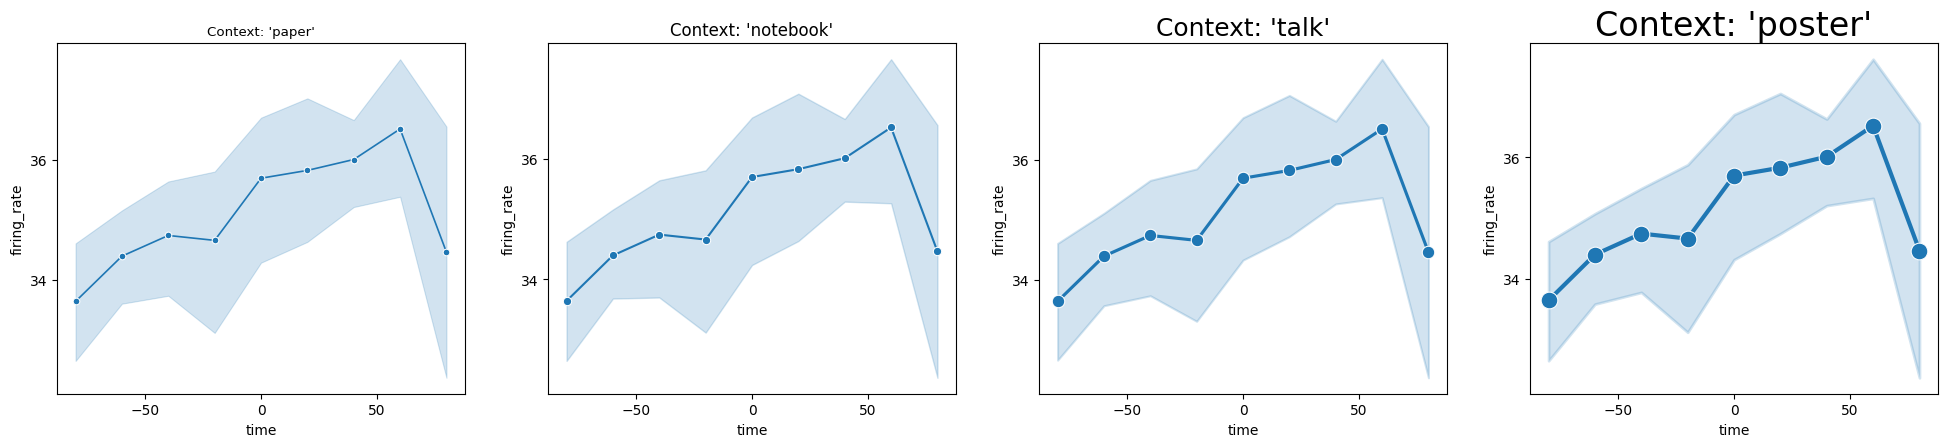

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data simpel
data = sns.load_dataset("dots").head(50) # Pakai data bawaan seaborn yang simpel
contexts = ['paper', 'notebook', 'talk', 'poster']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, ctx in zip(axes, contexts):
    # Terapkan tema berdasarkan context
    sns.set_theme(context=ctx, style='whitegrid')

    # Gambar plot simpel
    sns.lineplot(data=data, x="time", y="firing_rate", ax=ax, marker="o")

    ax.set_title(f"Context: '{ctx}'")

plt.tight_layout()
plt.show()

# Reset ke default agar tidak mempengaruhi plot berikutnya
sns.set_theme()

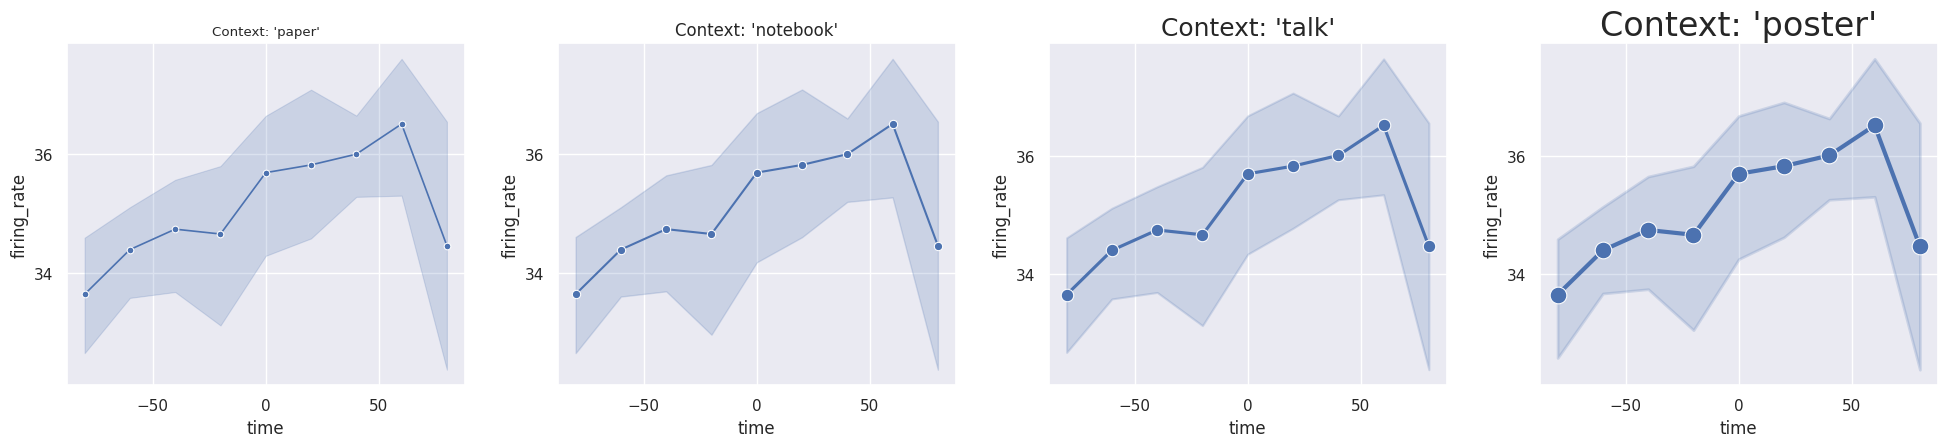

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data simpel
# Memuat dataset "dots" dari seaborn (bawaan) dan mengambil 50 baris pertama
# Dataset ini berisi tentang waktu vs firing rate neuron
data = sns.load_dataset("dots").head(50)  # head(50) = ambil 50 record pertama

# Daftar context yang akan dibandingkan
# 'paper'    : untuk jurnal/dokumen cetak (font kecil, garis tipis)
# 'notebook' : untuk Jupyter/Colab (ukuran standar)
# 'talk'     : untuk presentasi mengajar (font lebih tebal/besar)
# 'poster'   : untuk poster/banner besar (semua jadi raksasa)
contexts = ['paper', 'notebook', 'talk', 'poster']

# Membuat 1 baris dengan 4 kolom subplot (horizontal)
# figsize=(20, 5) : lebar 20 inci, tinggi 5 inci
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Loop melalui setiap axes dan context secara bersamaan
for ax, ctx in zip(axes, contexts):
    # Terapkan tema seaborn berdasarkan context yang sedang diproses
    # context : mengatur skala elemen plot (font, garis, marker)
    # style='whitegrid' : background putih dengan garis grid
    sns.set_theme(context=ctx, style='whitegrid')

    # Gambar line plot (plot garis) yang simpel
    # x = 'time' (waktu), y = 'firing_rate' (laju tembak neuron)
    # ax = subplot yang akan ditempati
    # marker='o' : beri marker lingkaran di setiap titik data
    sns.lineplot(data=data, x="time", y="firing_rate", ax=ax, marker="o")

    # Beri judul pada subplot sesuai context yang digunakan
    ax.set_title(f"Context: '{ctx}'")

# Mengatur layout agar elemen tidak terpotong atau tumpang tindih
plt.tight_layout()

# Menampilkan plot ke layar
plt.show()

# Reset ke default (seaborn theme bawaan)
# Ini penting agar plot berikutnya tidak terpengaruh oleh pengaturan context di atas
sns.set_theme()